In [2]:
import os
import glob
import importlib
import numpy as np
import pandas as pd
import pylab as pl
import seaborn as sns

In [6]:
import analyze2p.gratings.utils as gutils
import analyze2p.plotting as pplot
#import analyze2p.arousal.dlc_utils as dlcutils
import analyze2p.aggregate_datasets as aggr
import analyze2p.utils as hutils
import analyze2p.decoding as dec

In [7]:
#### Plotting params
visual_areas, area_colors = pplot.set_threecolor_palette()
pplot.set_plot_params(axis_labelsize=7, lw_axes=0.25)
bw_colors = dict((v, [0.7]*3) for v in visual_areas)
#### Set trace ID and FOV/state type
aggregate_dir = '/n/coxfs01/julianarhee/aggregate-visual-areas'
rootdir='/n/coxfs01/2p-data'
new_root = '/n/holylfs05/LABS/pfister_lab/Lab'
aggregate_dir = aggregate_dir.replace('/n', new_root)
rootdir = rootdir.replace('/n', new_root)

fov_type = 'zoom2p0x'
state = 'awake'
traceid = 'traces001'

In [8]:
%matplotlib notebook

In [9]:
experiment = 'blobs'
trial_epoch = 'stimulus'
responsive_test='ROC'
# ---------------------------------------------------------------
response_type='dff'
if responsive_test=='nstds':
    responsive_thr=7.0 if experiment=='rfs' else 10.
else:
    responsive_thr=0.05 if responsive_test=='ROC' else responsive_thr
resp_desc = '%s_responsive-%s-thr%.2f' \
                % (response_type, responsive_test, responsive_thr)
data_id = '|'.join([traceid, resp_desc])
print(data_id)
# ------------------------------------------------------------------
# Load all metdata and assigned cells
sdata, cells0 = aggr.get_aggregate_info(visual_areas=visual_areas, return_cells=True)
experiment_list = ['rfs10', 'rfs'] if experiment=='rfs' else [experiment]
meta = sdata[sdata.experiment.isin(experiment_list)].copy()

traces001|dff_responsive-ROC-thr0.05
/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/julianarhee/aggregate-visual-areas/dataset_info_assigned.pkl
Segmentation: missing 12 dsets


In [10]:
C_value=1.0
test_split=0.2
cv_nfolds=5
chance_level = 1/8. if experiment=='gratings' else 0.5

In [11]:
analysis_type='by_ncells'
# test_type='morph_single' #'morph_single'
test_type = 'morph'
class_name = 'morphlevel'
match_rfs = False
overlap_thr= 0.0 #[0, 0.25, 0.5]

test_str = 'default' if test_type is None else test_type
basedir = os.path.join(aggregate_dir, 'decoding', 'py3_%s' % analysis_type,
                      class_name, test_str)
if not os.path.exists(basedir):
    os.makedirs(basedir)
    print(basedir)
print(basedir)

/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/julianarhee/aggregate-visual-areas/decoding/py3_by_ncells/morphlevel/morph


## Output dirs

In [12]:
aggr_id = dec.create_aggregate_id(C_value=C_value, 
                            trial_epoch=trial_epoch,
                            responsive_test=responsive_test,
                            match_rfs=match_rfs, overlap_thr=overlap_thr)
if overlap_thr is not None and isinstance(overlap_thr, (list, np.ndarray)) or match_rfs:
    curr_dst_dir = os.path.join(basedir, 'controls')
else:
    curr_dst_dir = os.path.join(basedir, aggr_id)
if not os.path.exists(curr_dst_dir):
    os.makedirs(curr_dst_dir)
print(curr_dst_dir)
print(aggr_id)

/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/julianarhee/aggregate-visual-areas/decoding/py3_by_ncells/morphlevel/morph/dff-ROC__stimulus__overlap0.00__C1.00
dff-ROC__stimulus__overlap0.00__C1.00


In [13]:
importlib.reload(dec)

<module 'analyze2p.decoding' from '/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/2p-pipeline/repos/rat-2p-area-characterizations/analyze2p/decoding.py'>

## Load

In [14]:
iterdf, missing = dec.load_iterdf(meta, class_name,experiment=experiment,
                          analysis_type=analysis_type,
                          test_type=test_type,
                          traceid=traceid,
                          trial_epoch=trial_epoch, responsive_test=responsive_test, 
                          C_value=C_value, break_correlations=False, 
                          match_rfs=match_rfs, overlap_thr=overlap_thr)
print(iterdf['overlap_thr'].unique())
print(iterdf['morphlevel'].unique())

if test_type=='morph' and overlap_thr==0.0:
    max_ncells = 128
    iterdf = iterdf[iterdf['n_cells']<=max_ncells]
print(sorted(iterdf['n_cells'].unique()))


/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/2p-pipeline/repos/rat-2p-area-characterizations/analyze2p/decoding.py:2433: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for va, g in meta.groupby(['visual_area']):


(Li) Found 10 paths
(Lm) Found 10 paths
(V1) Found 10 paths
[0.]
[  0 106  -1  14  27  40  53  66  79  92]
[1, 2, 4, 8, 16, 32, 64, 96, 120, 128]


In [15]:
max_ncells = 128
iterdf = iterdf[iterdf['n_cells']<=max_ncells]

In [16]:
print(analysis_type, test_type)

grouper = ['morphlevel', 'intact', 'visual_area', 'condition', 'iteration']
if overlap_thr is not None and isinstance(overlap_thr, (list, np.ndarray)):
    grouper.append('overlap_thr')
# if test_type is not None:
#     grouper.append('novel')
mean_df = dec.average_within_iterations_by_ncells(iterdf,
                     analysis_type=analysis_type,
                         test_type=test_type, grouper=grouper) 
if test_type is not None:
    print("novel:", mean_df['novel'].unique())
print("conditions:", mean_df['condition'].unique())
print("morphs:", mean_df['morphlevel'].unique())

by_ncells morph
novel: [ True False]
conditions: ['data' 'shuffled']
morphs: [ -1   0  14  27  40  53  66  79  92 106]


/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/2p-pipeline/repos/rat-2p-area-characterizations/analyze2p/decoding.py:2586: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  mean_by_iters = iterdf.groupby(grouper).mean().reset_index()


In [17]:
max_ncells = 120 # if we set overlap_thr=0.0, must be GREATER than 0, so 120 cells only
# mean_df.groupby(['visual_area'])['n_cells'].max().min()
# print(max_ncells)
n_iters = iterdf['iteration'].max() +1
sample_sizes = [s for s in sorted(iterdf['n_cells'].unique()) if s <=max_ncells]
xlabels = [1, 32, 96, max_ncells]

In [18]:
# Get unique datasets/match cell #s
finaldf = iterdf[iterdf['n_cells']<=max_ncells].copy()
max_ncells = mean_df.groupby(['visual_area'])['n_cells'].max().min()
print(finaldf.shape)
finaldf['noise_corrs'] = ['intact' if f else 'shuffled' for f in finaldf['intact']]

(270000, 29)


In [19]:
finaldf['n_cells'].unique()

array([  2, 120,  32,  64,  16,   4,   1,   8,  96])

In [20]:
cols = ['visual_area', 'intact', 'n_cells'] 

columns='n_cells'
index = ['visual_area', 'intact']

if test_type=='morph_single':
    cols.append('train_transform')
    index.append('train_transform')

mean_ = finaldf[finaldf['morphlevel']==0] # get basic performance

if test_type is not None:
    score_table = mean_[~(mean_.novel) & (mean_.condition=='data')]\
            .groupby(cols)\
            .mean()['heldout_test_score'].reset_index()\
            .pivot_table(index=index, columns=columns)
else:
    score_table = mean_[(mean_.condition=='data')]\
            .groupby(cols)\
            .mean()['heldout_test_score'].reset_index()\
            .pivot_table(index=index, columns=columns)
score_table

/tmp/ipykernel_2098925/1312100837.py:13: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  score_table = mean_[~(mean_.novel) & (mean_.condition=='data')]\


heldout_test_score                                          \
n_cells                           1         2         4         8         16    
visual_area intact                                                              
Li          True             0.531915  0.554554  0.591111  0.635661  0.684939   
Lm          True             0.534240  0.558283  0.576105  0.609539  0.652690   
V1          True             0.542025  0.562230  0.592643  0.636782  0.673926   

                                                            
n_cells                  32        64        96        120  
visual_area intact                                          
Li          True    0.729881  0.756958  0.796843  0.828444  
Lm          True    0.702483  0.737345  0.758552  0.782310  
V1          True    0.726959  0.756862  0.782069  0.808310

# test_type='morph'

In [21]:
importlib.reload(pplot)

<module 'analyze2p.plotting' from '/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/2p-pipeline/repos/rat-2p-area-characterizations/analyze2p/plotting.py'>

In [22]:
count_cols = ['visual_area', 'morphlevel', 'condition', 'n_cells']
n_iterations = float(iterdf['iteration'].max()+1)
assert finaldf.groupby(count_cols).count().max().max()==n_iterations

In [23]:
finaldf.groupby(count_cols).count().max().max()

500

In [24]:
datad = finaldf[(finaldf.condition=='data') & (finaldf.intact)]
meandata_by_iter = datad.groupby(count_cols+['iteration']).mean()\
                     .reset_index()

meandata_by_iter = datad.groupby(count_cols+['iteration']).mean()\
                     .reset_index()
print(meandata_by_iter['morphlevel'].unique())

mean_by_iter = finaldf[finaldf.intact].groupby(count_cols+['iteration']).mean()\
                     .reset_index()

/tmp/ipykernel_2098925/2758169684.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  meandata_by_iter = datad.groupby(count_cols+['iteration']).mean()\
/tmp/ipykernel_2098925/2758169684.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  meandata_by_iter = datad.groupby(count_cols+['iteration']).mean()\


[ -1   0  14  27  40  53  66  79  92 106]


/tmp/ipykernel_2098925/2758169684.py:9: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  mean_by_iter = finaldf[finaldf.intact].groupby(count_cols+['iteration']).mean()\


In [25]:
%matplotlin notebook

UsageError: Line magic function `%matplotlin` not found.


In [26]:
mean_by_iter['n_cells'].max()

120

<IPython.core.display.Javascript object>


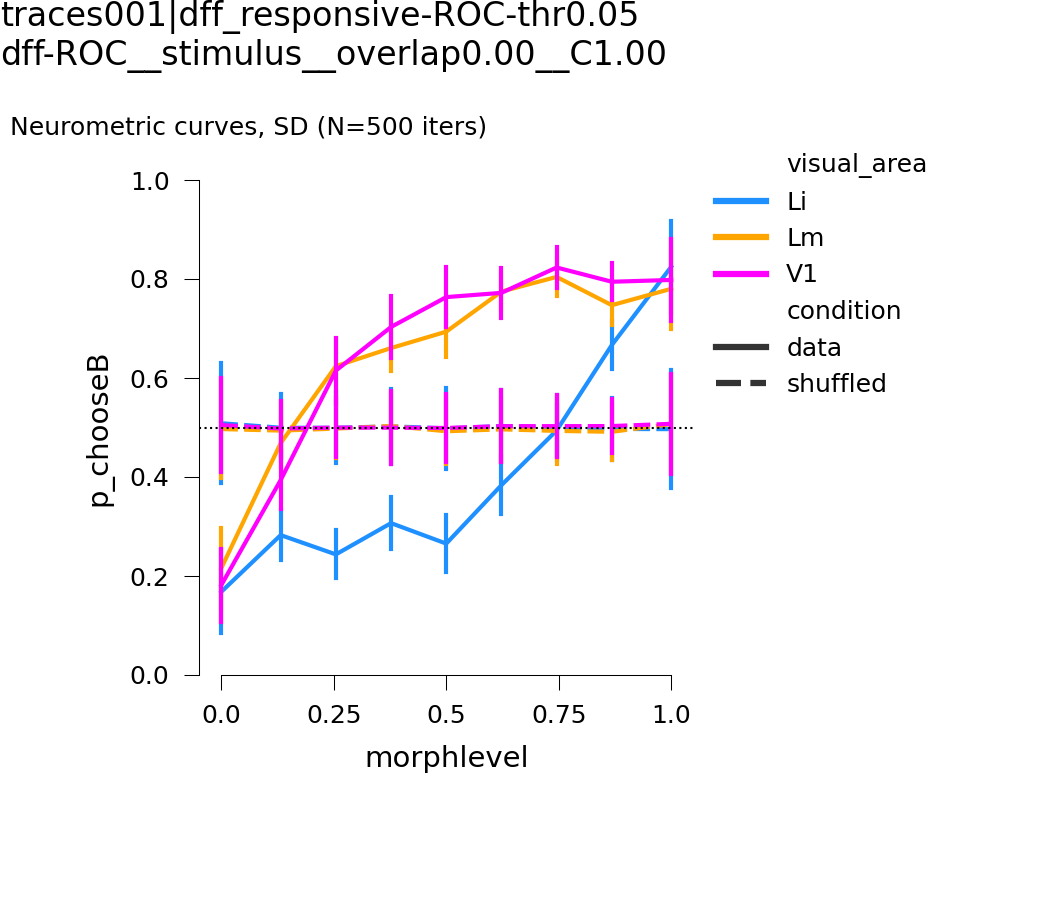

/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/2p-pipeline/repos/rat-2p-area-characterizations/analyze2p/decoding.py:2821: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(x='morphlevel', y=metric, ax=ax,


In [27]:
%matplotlib notebook
metric='p_chooseB'
curr_ncells = mean_by_iter['n_cells'].max() #max_ncells
plotd = mean_by_iter[mean_by_iter.n_cells==curr_ncells]\
            .groupby(['visual_area', 'morphlevel', 'iteration', 'condition']).mean().reset_index()

fig, ax = pl.subplots(figsize=(3.5, 3), dpi=150)
ax = dec.plot_pchooseb_by_area(plotd, #[plotd.condition=='data'], 
                        metric=metric, area_colors=area_colors, ax=ax)
ax.set_box_aspect(1)
pplot.label_figure(fig, '%s\n%s' % (data_id, aggr_id))
fig.text(0.01, 0.85, \
         'Neurometric curves, SD (N=%i iters)' % n_iterations, fontsize=6)
pl.subplots_adjust(left=0.1, right=0.75, bottom=0.25, top=0.8, wspace=0.5)

# figname = 'neurometric_sd_iters'
# pl.savefig(os.path.join(curr_dst_dir, '%s.svg' % figname))
# print(curr_dst_dir, figname)

In [28]:
importlib.reload(dec)

<module 'analyze2p.decoding' from '/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/2p-pipeline/repos/rat-2p-area-characterizations/analyze2p/decoding.py'>

<IPython.core.display.Javascript object>


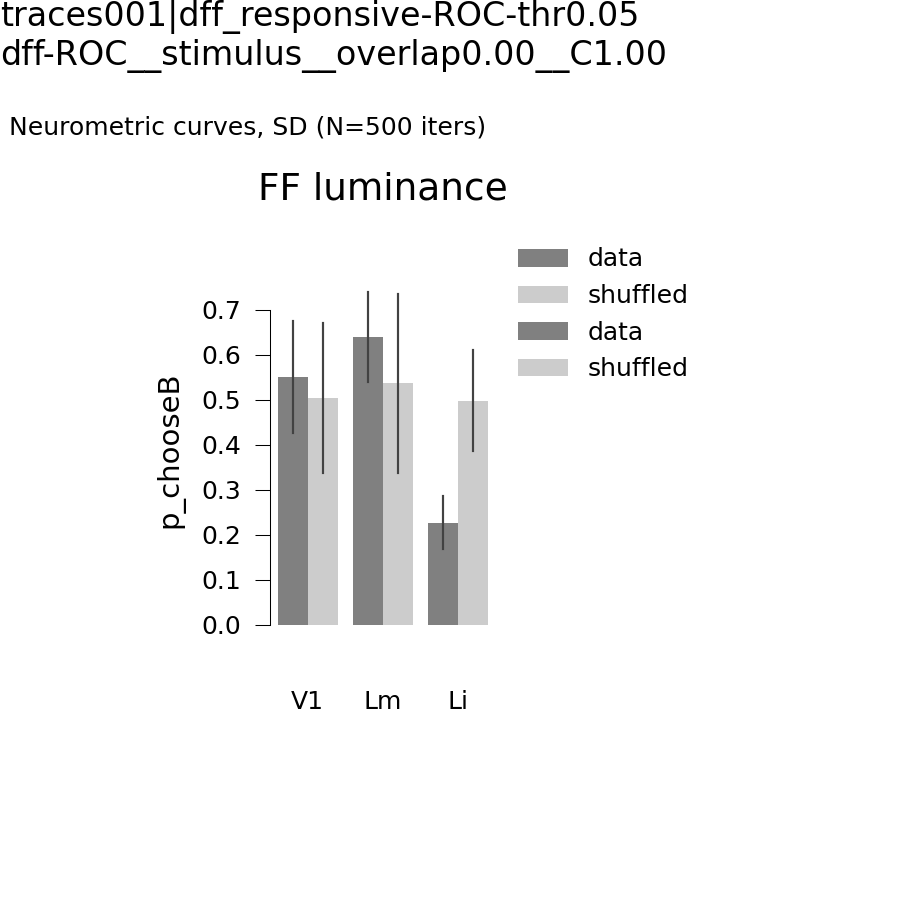

/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/2p-pipeline/repos/rat-2p-area-characterizations/analyze2p/decoding.py:2846: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='visual_area', y=metric, ax=ax,  hue='condition',
/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/2p-pipeline/repos/rat-2p-area-characterizations/analyze2p/decoding.py:2846: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='visual_area', y=metric, ax=ax,  hue='condition',


In [29]:
fig, ax = pl.subplots(figsize=(3, 3), dpi=150)
colors={'data': [0.5]*3, 'shuffled': [0.8]*3}
ax = dec.plot_pchooseb_lum_by_area(plotd, metric=metric, ax=ax, colors=colors)
ax.set_box_aspect(2)
ax.legend(bbox_to_anchor=(1,1), loc='upper left', frameon=False)

pplot.label_figure(fig, '%s\n%s' % (data_id, aggr_id))
fig.text(0.01, 0.85, \
         'Neurometric curves, SD (N=%i iters)' % n_iterations, fontsize=6)
pl.subplots_adjust(left=0.1, right=0.75, bottom=0.25, top=0.75, wspace=0.5)

ax = dec.plot_pchooseb_lum_by_area(plotd, metric=metric, ax=ax, colors=colors)
ax.legend(bbox_to_anchor=(1,1), loc='upper left', frameon=False)

# figname = 'luminance_pchooseB'
# pl.savefig(os.path.join(curr_dst_dir, '%s.svg' % figname))
# print(curr_dst_dir, figname)

<IPython.core.display.Javascript object>


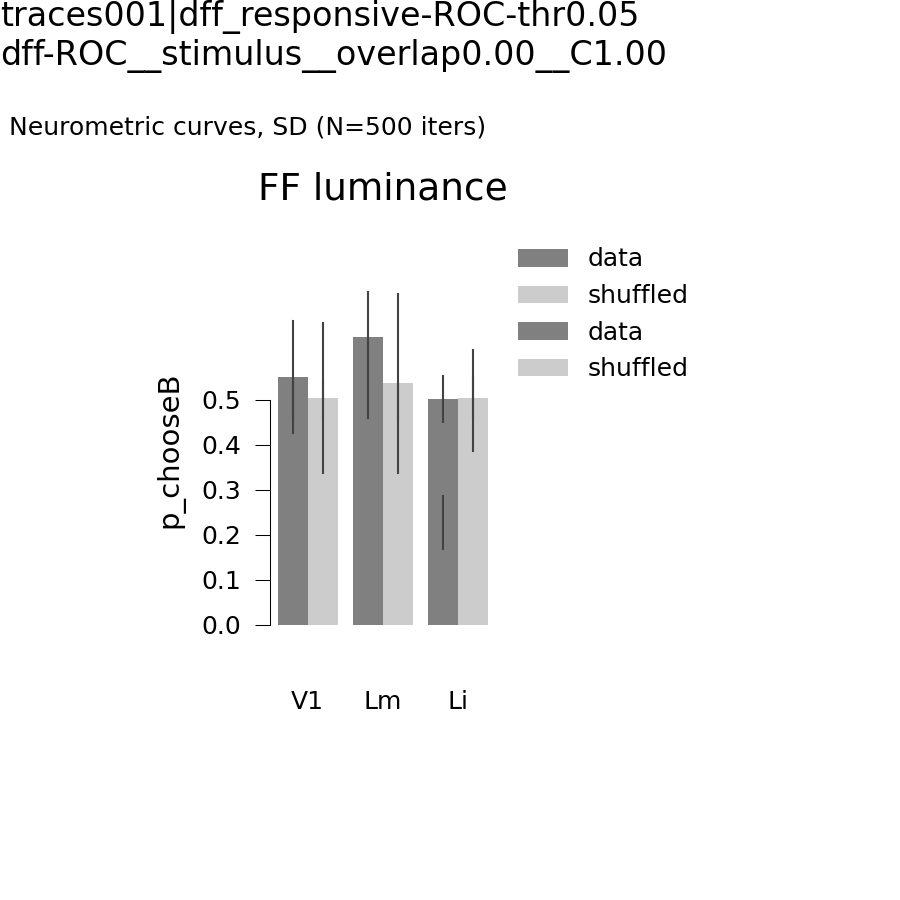

/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/2p-pipeline/repos/rat-2p-area-characterizations/analyze2p/decoding.py:2846: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='visual_area', y=metric, ax=ax,  hue='condition',
/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/2p-pipeline/repos/rat-2p-area-characterizations/analyze2p/decoding.py:2846: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='visual_area', y=metric, ax=ax,  hue='condition',


In [30]:
fig, ax = pl.subplots(figsize=(3, 3), dpi=150)
colors={'data': [0.5]*3, 'shuffled': [0.8]*3}
ax = dec.plot_pchooseb_lum_by_area(plotd, metric='heldout_test_score', 
                                   ax=ax, colors=colors)
ax.set_box_aspect(2)
ax.legend(bbox_to_anchor=(1,1), loc='upper left', frameon=False)

pplot.label_figure(fig, '%s\n%s' % (data_id, aggr_id))
fig.text(0.01, 0.85, \
         'Neurometric curves, SD (N=%i iters)' % n_iterations, fontsize=6)
pl.subplots_adjust(left=0.1, right=0.75, bottom=0.25, top=0.75, wspace=0.5)

ax = dec.plot_pchooseb_lum_by_area(plotd, metric=metric, ax=ax, colors=colors)
ax.legend(bbox_to_anchor=(1,1), loc='upper left', frameon=False)

# figname = 'luminance_pchooseB'
# pl.savefig(os.path.join(curr_dst_dir, '%s.svg' % figname))
# print(curr_dst_dir, figname)

## Fit params

In [31]:
iterdf.columns

Index(['fit_time', 'score_time', 'test_score', 'train_score',
       'heldout_test_score', 'C', 'randi', 'p_chooseB', 'morphlevel',
       'n_samples', 'condition', 'train_transform', 'test_transform', 'novel',
       'n_trials', 'iteration', 'threshold', 'width', 'lambda', 'gamma', 'eta',
       'jnd', 'randi_cells', 'n_cells', 'visual_area', 'datakey', 'intact',
       'noise_corrs', 'overlap_thr'],
      dtype='object')

In [32]:
cols = ['visual_area', 'n_cells', 'condition', 'intact']
fit_params = ['threshold', 'width', 'lambda', 'gamma', 'eta', 'jnd']
cols.extend(fit_params)
morphdf = mean_by_iter[mean_by_iter.morphlevel!=-1][cols].drop_duplicates()

df_ = morphdf[(morphdf.n_cells==max_ncells)].dropna()
# df_[fit_params] = df_[fit_params].round(4)
df_ = df_.rename(columns={'jnd': '2jnd'})
df_['jnd'] = df_['2jnd']/2.
cond_colors={'data': [0.5]*3, 'shuffled': [0.8]*3}

In [33]:
df_[df_['condition']=='data']

,visual_area,n_cells,condition,intact,threshold,width,lambda,gamma,eta,2jnd,jnd
13000,Li,120,data,1.0,0.833239,0.905340,3.347734e-08,2.353586e-01,4.019397e-08,0.371244,0.185622
13001,Li,120,data,1.0,0.819614,0.681667,3.884235e-06,2.038258e-01,4.669565e-09,0.279525,0.139762
13002,Li,120,data,1.0,0.832499,0.600556,3.005847e-09,2.382429e-01,7.978843e-09,0.246264,0.123132
13003,Li,120,data,1.0,0.857660,0.544827,1.774520e-04,2.361112e-01,2.200591e-07,0.223412,0.111706
13004,Li,120,data,1.0,0.819092,0.742783,3.085631e-08,2.241657e-01,1.824427e-04,0.304586,0.152293
...,...,...,...,...,...,...,...,...,...,...,...
197995,V1,120,shuffled,1.0,1.060473,0.242186,1.179191e-08,4.345253e-01,6.288383e-02,0.099311,0.049656
197996,V1,120,shuffled,1.0,1.190881,1.480130,1.832440e-09,4.556147e-01,6.211853e-06,0.606943,0.303471
197997,V1,120,shuffled,1.0,-0.030020,0.396892,5.028237e-01,1.425931e-07,1.466859e-04,0.162750,0.081375
197998,V1,120,shuffled,1.0,1.153721,0.239147,2.016135e-07,4.591612e-01,1.759393e-04,0.098065,0.049032


In [34]:
for param in ['threshold', 'jnd']:
    print('%s ----------------------------' % param)
    print(df_.groupby('visual_area')[param].describe().round(2))
    
# morphdf[morphdf.condition=='data'].groupby('visual_area').describe()

threshold ----------------------------
              count  mean   std   min   25%   50%   75%   max
visual_area                                                  
Li           1000.0  0.68  0.45 -0.22  0.69  0.84  1.00  1.22
Lm            999.0  0.31  0.49 -0.23  0.00  0.08  1.03  1.24
V1           1000.0  0.33  0.47 -0.23  0.07  0.13  1.02  1.26
jnd ----------------------------
              count  mean   std   min   25%   50%   75%   max
visual_area                                                  
Li           1000.0  0.13  0.08  0.04  0.05  0.12  0.16  0.45
Lm            999.0  0.13  0.07  0.05  0.05  0.13  0.19  0.39
V1           1000.0  0.12  0.07  0.05  0.05  0.11  0.15  0.46


In [35]:
for param in ['threshold', 'jnd']:
    print('%s ----------------------------' % param)
    print(df_[df_['condition']=='data'].groupby('visual_area')[param].describe().round(2))
    

threshold ----------------------------
             count  mean   std   min   25%   50%   75%   max
visual_area                                                 
Li           500.0  0.83  0.05  0.56  0.82  0.84  0.86  0.94
Lm           500.0  0.08  0.04 -0.06  0.06  0.08  0.10  0.20
V1           500.0  0.14  0.04  0.04  0.11  0.13  0.16  0.38
jnd ----------------------------
             count  mean   std   min   25%   50%   75%   max
visual_area                                                 
Li           500.0  0.16  0.07  0.06  0.12  0.14  0.17  0.45
Lm           500.0  0.18  0.05  0.05  0.14  0.18  0.21  0.39
V1           500.0  0.14  0.05  0.05  0.11  0.13  0.16  0.46


In [36]:
pplot.set_plot_params()

In [58]:
len(fit_params)

2

<IPython.core.display.Javascript object>


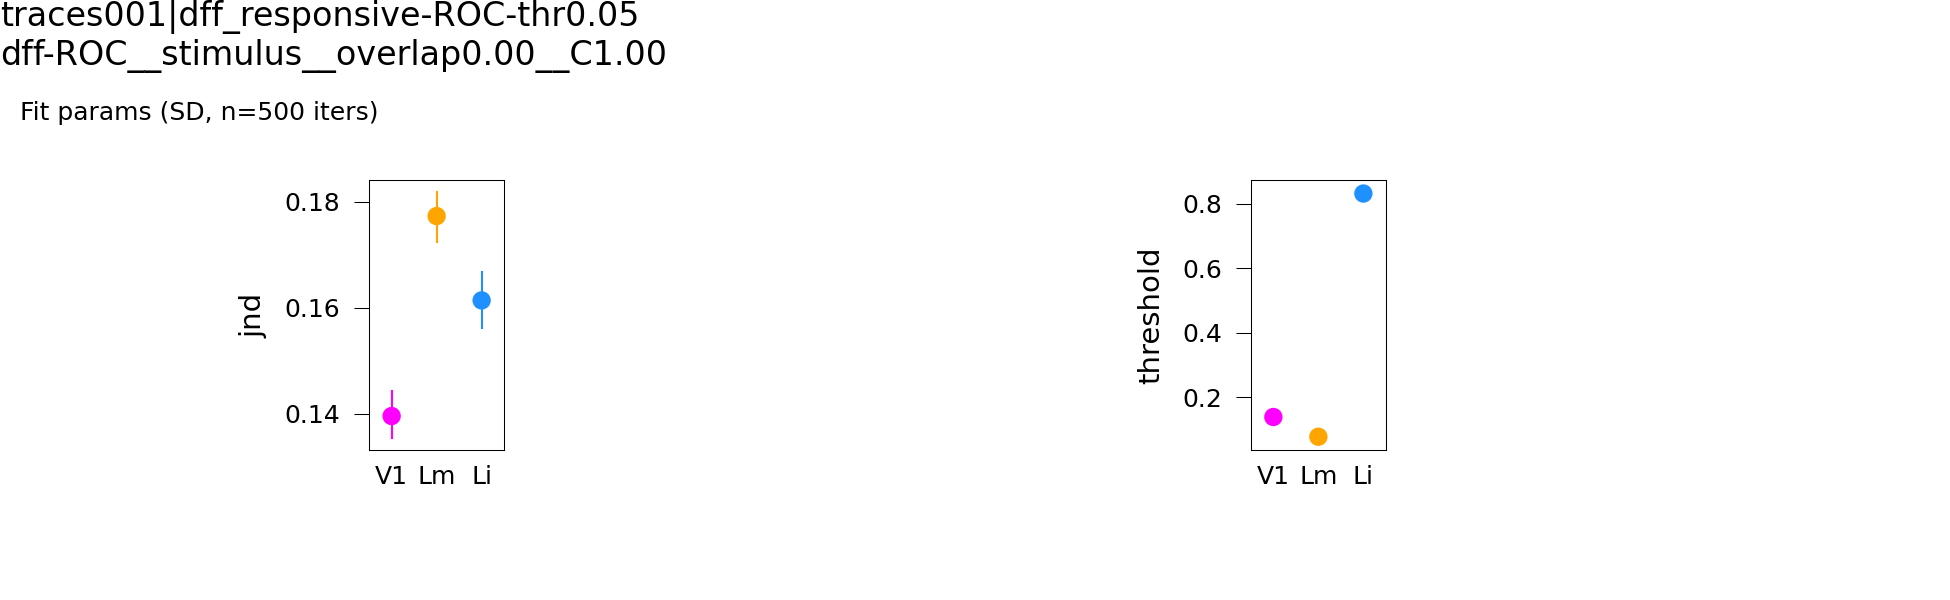

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


param:  jnd
{'jnd': {'V1': (0.1355254020609541, 0.1443180450814594), 'Lm': (0.17229844295626293, 0.1817538908144471), 'Li': (0.15612433398340475, 0.166664517945349)}}
param:  threshold
{'jnd': {'V1': (0.1355254020609541, 0.1443180450814594), 'Lm': (0.17229844295626293, 0.1817538908144471), 'Li': (0.15612433398340475, 0.166664517945349)}, 'threshold': {'V1': (0.13490846975877474, 0.14200254870767812), 'Lm': (0.07414345271311913, 0.08035311090030837), 'Li': (0.826777081913708, 0.8348236363595563)}}


In [73]:
%matplotlib notebook
fit_params = ['jnd', 'threshold'] #'threshold', 'jnd']
ci_values={}
plotd = df_[df_.condition=='data'].copy()
fig, axn = pl.subplots(1, len(fit_params), figsize=(6.5,2), dpi=150)
for ax, param in zip(axn.flat, fit_params):
    print("param: ", param)
    sns.pointplot(x='visual_area', y=param, data=plotd, ax=ax,
                   palette=area_colors, order=visual_areas,
                   join=True, #ci='sd', #dodge=0.5,
                   scale=0.5, errwidth=0.5)
    ax.set_box_aspect(2)
    ax.tick_params(which='both', axis='x', size=0)
    ax.set_xlabel('')
    # Get confidence interval values
    ci_values[param] = {}
    for bar in ax.get_children():
        #if isinstance(child, pl.ErrorbarContainer):
        #for bar in child.get_children():
        if isinstance(bar, pl.Line2D):
            x_data = bar.get_xdata()
            y_data = bar.get_ydata()
            category = visual_areas[x_data[0]] 
            #data['Category'].unique()[int(x_data[0])]
            ci_values[param][category] = (y_data[0], y_data[1])
    # Print the confidence interval values
    print(ci_values)

#sns.despine(bottom=True)
axn[-1].legend(bbox_to_anchor=(1,1), loc='lower right', frameon=False)
pl.subplots_adjust(left=0.05, right=0.85, bottom=0.25, top=0.7, wspace=0.3)
fig.text(0.01, 0.8, 'Fit params (SD, n=%i iters)' % n_iterations)
pplot.label_figure(fig, '%s\n%s' % (data_id, aggr_id))

# figname = 'fit_params'
# pl.savefig(os.path.join(curr_dst_dir, '%s.svg' % figname))
# print(curr_dst_dir, figname)

In [74]:
ci_values

{'jnd': {'V1': (0.1355254020609541, 0.1443180450814594),
  'Lm': (0.17229844295626293, 0.1817538908144471),
  'Li': (0.15612433398340475, 0.166664517945349)},
 'threshold': {'V1': (0.13490846975877474, 0.14200254870767812),
  'Lm': (0.07414345271311913, 0.08035311090030837),
  'Li': (0.826777081913708, 0.8348236363595563)}}

In [69]:
child.get_children()

[]

In [64]:
bar = ax.get_children()[0]
isinstance(bar, pl.Line2D)

True

In [65]:
bar.get_ydata()

array([0.1353794, 0.1446657])

In [66]:
bar.get_xdata()

array([0, 0])

# Stats?

In [52]:
plotd.groupby(['visual_area'])['jnd'].describe()

,count,mean,std,min,25%,50%,75%,max
visual_area,,,,,,,,
Li,500.0,0.161390,0.065009,0.056115,0.124167,0.143276,0.174613,0.449049
Lm,500.0,0.177271,0.053605,0.048688,0.140990,0.176234,0.209469,0.391949
V1,500.0,0.139612,0.051547,0.047105,0.107627,0.127827,0.160307,0.455819


In [53]:
thr_stats = plotd.groupby(['visual_area'])['threshold'].describe()
thr_stats

,count,mean,std,min,25%,50%,75%,max
visual_area,,,,,,,,
Li,500.0,0.830942,0.046756,0.561968,0.815873,0.836054,0.855317,0.936760
Lm,500.0,0.077210,0.036224,-0.059679,0.057385,0.079890,0.100399,0.197802
V1,500.0,0.138350,0.039854,0.035297,0.112966,0.132403,0.157310,0.381571


In [54]:
z = 1.96
def get_ci(thr_stats, va='V1', z=1.96):
    x_hat = thr_stats.loc[va]['mean']
    std = thr_stats.loc[va]['std']
    n = thr_stats.loc[va]['count']
    
    ci_plus = x_hat + z*(std/np.sqrt(n))
    ci_minus = x_hat - z*(std/np.sqrt(n))
    return (ci_minus, ci_plus)

In [48]:
    x_hat = thr_stats.loc[va]['mean']
    std = thr_stats.loc[va]['std']
    n = thr_stats.loc[va]['count']
    x_hat, z*(std/np.sqrt(n))

(0.8309420629316059, 0.004098306112634274)

In [50]:
x_hat + z*(std/np.sqrt(n))

0.8350403690442402

In [51]:
ci = get_ci(thr_, va=va)
ci

(0.8268437568189716, 0.8350403690442402)

In [55]:
plotd[plotd['visual_area']=='V1'].shape

(500, 11)

In [46]:
print("Threshold CIs -----------------------")
thr_ = plotd.groupby(['visual_area'])['threshold'].describe()
thr_cis = {}
for va in visual_areas:
    ci = get_ci(thr_, va=va) #.loc['Li']
    thr_cis.update({va: ci})
    print('{} (95% CI={:.2f},{:.2f})'.format(va, round(ci[0], 2), round(ci[1],2)))
    
print("JND CIs -----------------------")
jnd_ = plotd.groupby(['visual_area'])['jnd'].describe()
jnd_cis = {}
for va in visual_areas:
    ci = get_ci(jnd_, va=va) #.loc['Li']
    jnd_cis.update({va: ci})
    print('{} (95% CI={:.2f},{:.2f})'.format(va, round(ci[0],2), round(ci[1], 2)))

Threshold CIs -----------------------
V1 (95% CI=0.13,0.14)
Lm (95% CI=0.07,0.08)
Li (95% CI=0.83,0.84)
JND CIs -----------------------
V1 (95% CI=0.14,0.14)
Lm (95% CI=0.17,0.18)
Li (95% CI=0.16,0.17)


In [44]:
for va, vals in thr_cis.items():
    print('{} (95% CI={:.2f},{:.2f})'.format(va, vals[0], vals[1]))

V1 (95% CI=0.13,0.14)
Lm (95% CI=0.07,0.08)
Li (95% CI=0.83,0.84)


In [65]:
import scipy.stats as spstats
from itertools import combinations
import statsmodels.stats.multitest as smm

<IPython.core.display.Javascript object>


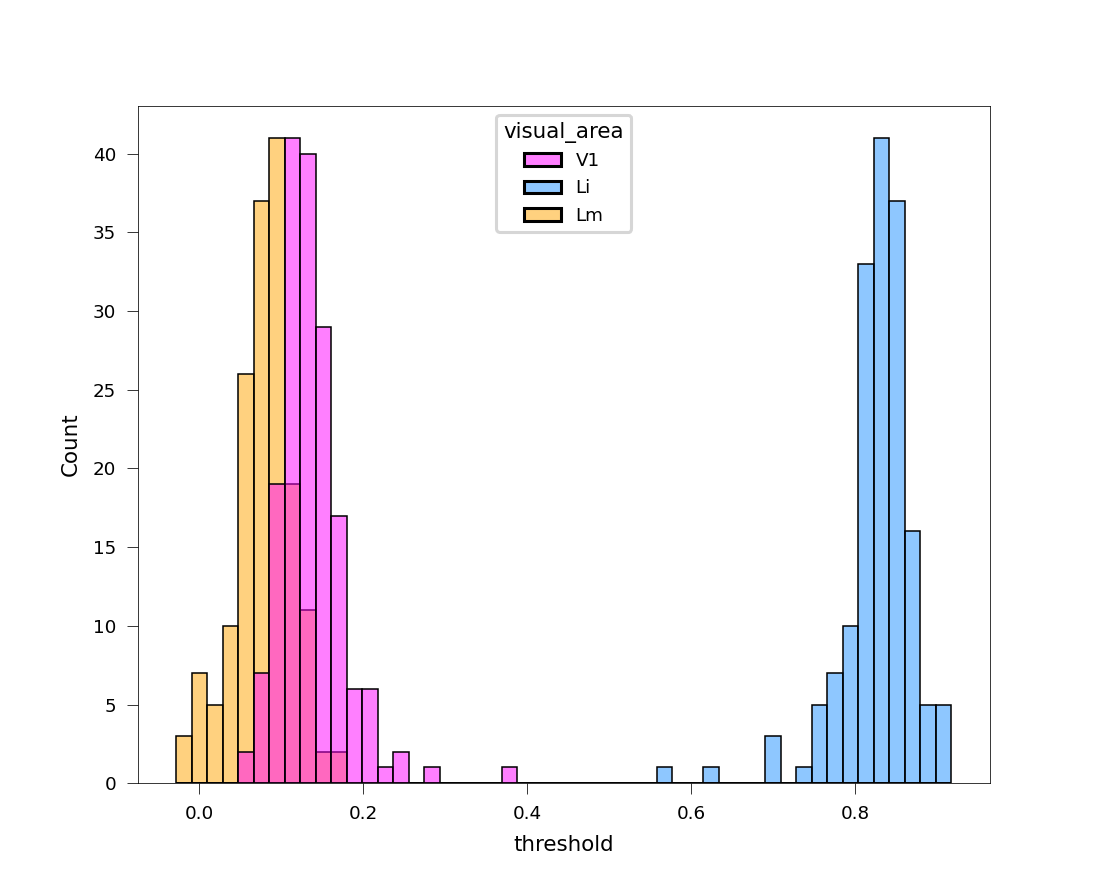

<AxesSubplot:xlabel='threshold', ylabel='Count'>

In [126]:
fig, ax =pl.subplots()
sns.histplot(data=plotd.sample(500), x='threshold', ax=ax,
             hue='visual_area', palette=area_colors, bins=50)

In [122]:
metric = 'threshold'
gen_vals = plotd[['visual_area', metric]].copy()
#perform Kolmogorov-Smirnov test
results = {}
groups = ['V1', 'Lm', 'Li']

for group1, group2 in combinations(groups, 2):
    ks_stat, p_value = spstats.mannwhitneyu(
                gen_vals[gen_vals['visual_area']==group1][metric].sample(50), 
                gen_vals[gen_vals['visual_area']==group2][metric].sample(50))
    results[f"{group1},{group2}"] = (ks_stat, p_value)

# Apply Bonferroni correction
adjusted_p_values = smm.multipletests([r[1] for r in results.values()], 
                                      method='bonferroni')[1]
# Print results
true_ks = []
i = 0
for (comparison, (ks_stat, p)), adj_p in zip(results.items(), adjusted_p_values):
    print(f"{comparison}: KS-stat={ks_stat:.2f}, p={p:.2e}, adjusted p={adj_p:.2e}")
    
    ks = pd.DataFrame({'comparison': comparison,
                       'A': comparison.split(',')[0],
                       'B': comparison.split(',')[1],
                         'ks_stat': ks_stat,
                         'p': p,
                         'adjusted_p': adj_p}, index=[i])
    i+=1
    true_ks.append(ks)
true_ks = pd.concat(true_ks)
true_ks

V1,Lm: KS-stat=2238.00, p=9.92e-12, adjusted p=2.98e-11
V1,Li: KS-stat=0.00, p=7.07e-18, adjusted p=2.12e-17
Lm,Li: KS-stat=0.00, p=7.07e-18, adjusted p=2.12e-17


,comparison,A,B,ks_stat,p,adjusted_p
0,"V1,Lm",V1,Lm,2238.0,9.920783e-12,2.976235e-11
1,"V1,Li",V1,Li,0.0,7.066072e-18,2.119822e-17
2,"Lm,Li",Lm,Li,0.0,7.066072e-18,2.119822e-17


In [131]:
gen_vals = plotd[['visual_area', metric]].copy()
true_means = gen_vals.groupby('visual_area').mean()
true_means

,threshold
visual_area,
Li,0.830942
Lm,0.077210
V1,0.138350


In [128]:
shuff_vals = gen_vals.copy()

i_list = []
for i in range(1000):
    shuff_vals['visual_area'] = shuff_vals['visual_area'].sample(frac=1).values

    shuff_means = shuff_vals.groupby('visual_area').mean().reset_index()
    i_list.append(shuff_means)
shuffled = pd.concat(i_list)

<IPython.core.display.Javascript object>


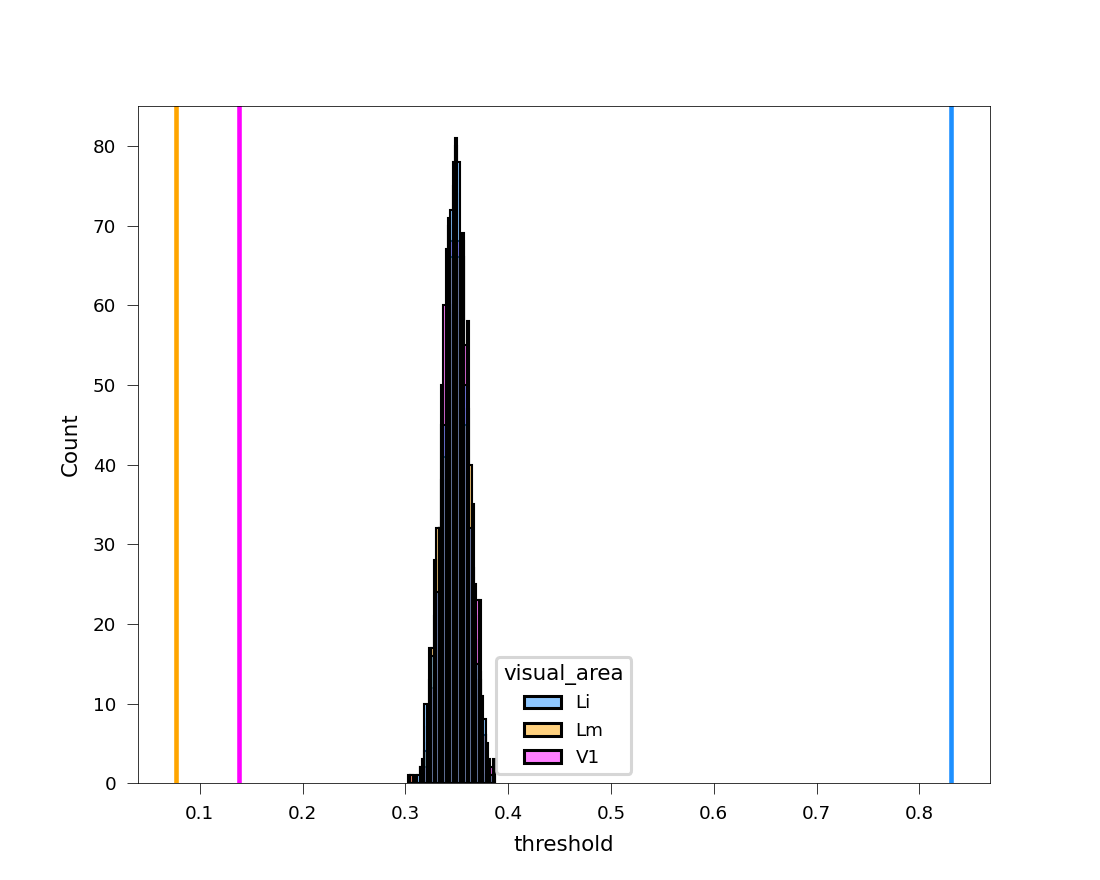

In [139]:
fig, ax = pl.subplots()
sns.histplot(data=shuffled, x='threshold', ax=ax,
            hue='visual_area', palette=area_colors)

for va, val in true_means.groupby('visual_area'):
    ax.axvline(x=float(val.iloc[0]), color=area_colors[va])

In [133]:
for va, val in true_means.groupby('visual_area'):
    print(val)

             threshold
visual_area           
Li            0.830942
             threshold
visual_area           
Lm             0.07721
             threshold
visual_area           
V1             0.13835


In [26]:
plotd.groupby(['visual_area'])['jnd'].describe()

,count,mean,std,min,25%,50%,75%,max
visual_area,,,,,,,,
Li,500.0,0.322780,0.130017,0.1122,0.248350,0.28655,0.349250,0.8981
Lm,500.0,0.354543,0.107211,0.0974,0.281975,0.35245,0.418900,0.7839
V1,500.0,0.279224,0.103093,0.0942,0.215225,0.25565,0.320625,0.9116


In [27]:
plotd.groupby(['visual_area'])['threshold'].describe()

,count,mean,std,min,25%,50%,75%,max
visual_area,,,,,,,,
Li,500.0,0.830941,0.046754,0.5620,0.815875,0.83605,0.855350,0.9368
Lm,500.0,0.077210,0.036223,-0.0597,0.057400,0.07990,0.100375,0.1978
V1,500.0,0.138352,0.039857,0.0353,0.112975,0.13240,0.157275,0.3816


In [25]:
import analyze2p.objects.neurometric as nutils

In [26]:
opts = nutils.default_options(yesno=True)
meanpar = df_[df_.condition=='data'].median()
shuffpar = df_[df_.condition=='shuffled'].median()
# fh = getSig.getSigmoidHandle(opts)

In [27]:
xmin=0
xmax=1
npoints=9
importlib.reload(nutils)

<module 'analyze2p.objects.neurometric' from '/net/coxfs01/srv/export/coxfs01/share_root/2p-pipeline/repos/rat-2p-area-characterizations/analyze2p/objects/neurometric.py'>

In [28]:
f_=[]
for (va, cond), g in df_.groupby(['visual_area', 'condition']):
    for ix, ig in g.iterrows():
        # print(ig)
        fh = opts['sigmoidHandle']
        try:
            fvs = nutils.get_fit_values(pd.DataFrame(ig).T, fh, 
                                    xmin=xmin, xmax=xmax, npoints=npoints,
                                    add_cols=['visual_area', 'condition'])
            f_.append(fvs)
        except Exception as e:
            pass
fitvs = pd.concat(f_)

<IPython.core.display.Javascript object>


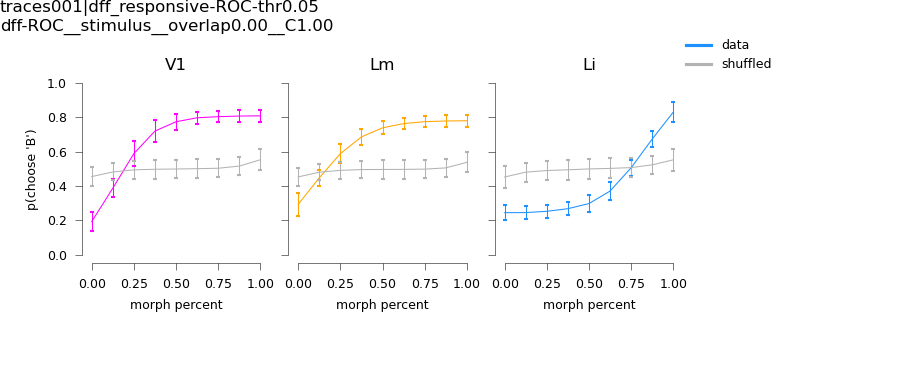

/n/coxfs01/julianarhee/aggregate-visual-areas/decoding/py3_by_ncells/morphlevel/morph/dff-ROC__stimulus__overlap0.00__C1.00 neurometric_fits_120cells


In [32]:
fig, axn = pl.subplots(1,3, figsize=(6,2.5), dpi=150, sharex=True, sharey=True)
for va, vg in fitvs.groupby('visual_area'):
    ax=axn[visual_areas.index(va)]
    sns.lineplot(data=vg, ax=ax,
            x='x', y='fitv', hue='condition',
            err_style='bars', ci='sd',  lw=0.5, 
            err_kws={'elinewidth':0.5, 'capsize':1},
            palette={'data': area_colors[va], 'shuffled': [0.7]*3},
            estimator=np.median) #, err_kws={'errwidth':0.5})
    ax.set_ylim([0,1])
    ax.set_xlabel('morph percent')
    ax.set_ylabel("p(choose 'B')")
    ax.set_xlim([-0.01,1.01])
    ax.set_box_aspect(1)
    ax.legend_.remove()
    ax.set_title(va)
    
sns.despine(trim=True, offset=4)
pl.subplots_adjust(left=0.1, right=0.75, bottom=0.3, top=0.8)
axn[-1].legend(bbox_to_anchor=(1,1), loc='lower left', frameon=False)

pplot.label_figure(fig, '%s\n%s' % (data_id, aggr_id))

figname = 'neurometric_fits_%icells' % max_ncells
pl.savefig(os.path.join(curr_dst_dir, '%s.svg' % figname))
print(curr_dst_dir, figname)


In [33]:
importlib.reload(pplot)

<module 'analyze2p.plotting' from '/net/coxfs01/srv/export/coxfs01/share_root/2p-pipeline/repos/rat-2p-area-characterizations/analyze2p/plotting.py'>

/n/coxfs01/2p-pipeline/envs/rat2p/lib/python3.7/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.
/n/coxfs01/2p-pipeline/envs/rat2p/lib/python3.7/site-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """


<IPython.core.display.Javascript object>


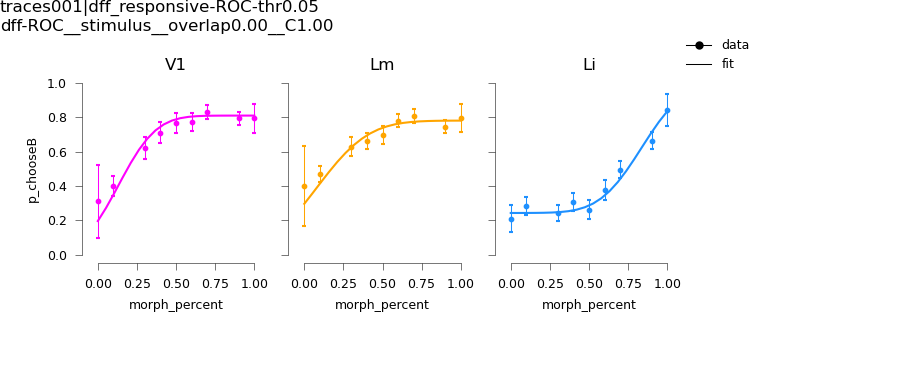

/n/coxfs01/julianarhee/aggregate-visual-areas/decoding/py3_by_ncells/morphlevel/morph/dff-ROC__stimulus__overlap0.00__C1.00 neurometric_data_and_fits_120cells


In [34]:
%matplotlib notebook
curr_ncells = max_ncells
plotd = meandata_by_iter[(meandata_by_iter.n_cells==curr_ncells)]
plotd['morph_percent'] = (plotd['morphlevel']/106.).round(1)
plotd['morph_percent'] = plotd['morph_percent'].astype(float)
fig, axn = pl.subplots(1,3, figsize=(6,2.5), dpi=150, sharex=True, sharey=True)

for va, vg in plotd.groupby('visual_area'):
    ax=axn[visual_areas.index(va)]
    sns.lineplot(x='morph_percent', y=metric, data=vg[vg.condition=='data'], ax=ax,
                  estimator=np.median, err_style='bars',
                  color=area_colors[va], ci='sd',
                  err_kws={'capsize': 1, 'elinewidth': 0.5}, 
                  lw=0, markers=['o']*9, style='morph_percent', dashes=False,
                  mec=None, markersize=2)

    xtick_pp = sorted(ax.get_xticks())
    opts = nutils.default_options(yesno=True)
    meanpar = vg[vg.condition=='data'].median()
    # shuffpar = vg[vg.condition=='shuffled'].median()
    nutils.plot_sigmoid_from_params(meanpar[fit_params].values, opts, ax=ax, 
                                xmin=0, xmax=1, npoints=20, lc=area_colors[va])
    ax.set_ylim([0, 1])
    #pplot.set_morph_xticks(ax)
    ax.set_box_aspect(1)
    ax.set_title(va)
    ax.legend_.remove()

leg_h = pplot.custom_legend_markers(colors=['k', 'k'],
                                   labels=['data', 'fit'], markers=['.', None])
axn[-1].legend(handles=leg_h, bbox_to_anchor=(1,1), loc='lower left', frameon=False)

sns.despine(trim=True, offset=4)
pl.subplots_adjust(left=0.1, right=0.75, bottom=0.3, top=0.8)
pplot.label_figure(fig, '%s\n%s' % (data_id, aggr_id))

figname = 'neurometric_data_and_fits_%icells' % max_ncells
pl.savefig(os.path.join(curr_dst_dir, '%s.svg' % figname))
print(curr_dst_dir, figname)

In [35]:
meanpar[fit_params]

threshold    1.324030e-01
width        6.234560e-01
lambda       1.910268e-01
gamma        1.556702e-07
eta          3.022429e-07
jnd          2.556548e-01
dtype: float64

## Plot by_ncells

In [36]:
morphdf = mean_by_iter[mean_by_iter.morphlevel!=-1]\
            .groupby(['visual_area', 'condition', 'n_cells']).median().reset_index()
npoints=9
f_=[]
for (va, cond, nc), g in morphdf.groupby(['visual_area', 'condition', 'n_cells']):
    for ix, ig in g.iterrows():
        fh = opts['sigmoidHandle']
        try:
            fvs = nutils.get_fit_values(pd.DataFrame(ig).T, fh, 
                                    xmin=xmin, xmax=xmax, npoints=npoints,
                                    add_cols=['visual_area', 'condition', 'n_cells'])
            f_.append(fvs)
        except Exception as e:
            pass
fitvs = pd.concat(f_, ignore_index=True)
fitvs = fitvs.rename(columns={'x': 'morphlevel', 'fitv': 'p_chooseB'})

In [37]:
fitvs[fitvs.visual_area=='V1']

,morphlevel,p_chooseB,visual_area,condition,n_cells
324,0.000,0.537533,V1,data,1
325,0.125,0.692354,V1,data,1
326,0.250,0.742781,V1,data,1
327,0.375,0.751155,V1,data,1
328,0.500,0.751862,V1,data,1
...,...,...,...,...,...
481,0.500,0.394568,V1,shuffled,120
482,0.625,0.394568,V1,shuffled,120
483,0.750,0.394655,V1,shuffled,120
484,0.875,0.410535,V1,shuffled,120


<IPython.core.display.Javascript object>


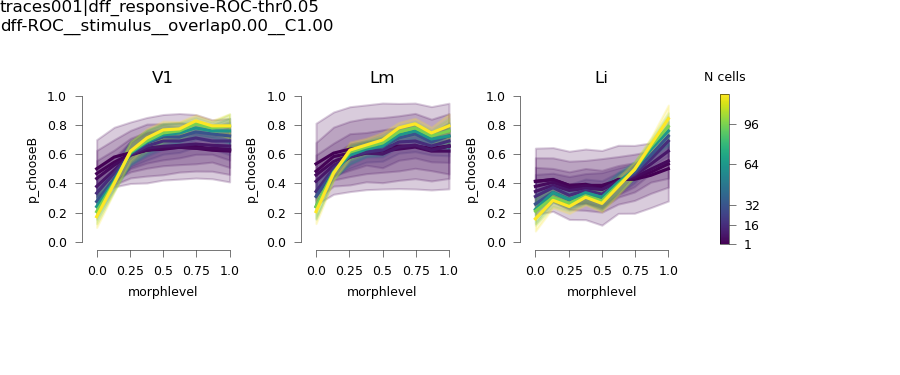

/n/coxfs01/julianarhee/aggregate-visual-areas/decoding/py3_by_ncells/morphlevel/morph/dff-ROC__stimulus__overlap0.00__C1.00 neurometric_byncells_plotraw


In [38]:
%matplotlib notebook
min_n = meandata_by_iter['n_cells'].min()
max_n = meandata_by_iter['n_cells'].max()
ncells_list = sorted(meandata_by_iter['n_cells'].unique())

cmap='viridis'
plot_fits = False

plot_type = 'plotfits' if plot_fits else 'plotraw'

if plot_fits:
    plotd = fitvs[fitvs.condition=='data'].copy()
else:
    plotd = mean_by_iter[(mean_by_iter.morphlevel!=-1)
                            & (mean_by_iter.condition=='data')].copy()

fig, axn = pl.subplots(1,3, figsize=(6, 2.5), dpi=150, sharex=True)
for va, vg in plotd.groupby('visual_area'):
    ax=axn[visual_areas.index(va)]
    sns.lineplot(x='morphlevel', y=metric, data=vg, ax=ax,
             hue='n_cells', palette=cmap, hue_norm=(min_n, max_n), ci='sd',
             estimator=np.median)
    ax.set_ylim([0, 1])
    if not plot_fits:
        pplot.set_morph_xticks(ax)
    ax.set_box_aspect(1)
    ax.set_title(va)
    ax.legend_.remove()
sns.despine(trim=True, offset=4)

# Define a new Axes where the colorbar will go
cax = fig.add_axes([.8, .35, .01, .4])
# Get a mappable object with the same colormap as the data
points = pl.scatter([], [], c=[], vmin=min_n, vmax=max_n, cmap=cmap)
# Draw the colorbar
cb = fig.colorbar(points, cax=cax)
cax.set_title('N cells', fontsize=6)
cb.set_ticks([1, 16, 32, 64, 96, 128])

pl.subplots_adjust(left=0.1, right=0.75, bottom=0.2, top=0.9, wspace=0.5)

pplot.label_figure(fig, '%s\n%s' % (data_id, aggr_id))

figname = 'neurometric_byncells_%s' % plot_type
pl.savefig(os.path.join(curr_dst_dir, '%s.svg' % figname))
print(curr_dst_dir, figname)

In [39]:
cax.set_t

AttributeError: 'Axes' object has no attribute 'set_t'

<IPython.core.display.Javascript object>


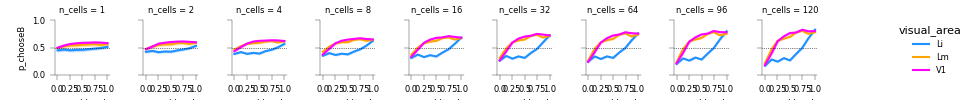

In [40]:
%matplotlib notebook
min_n = meandata_by_iter['n_cells'].min()
max_n = meandata_by_iter['n_cells'].max()

ncell_list = sorted(meandata_by_iter['n_cells'].unique())
col_list = sns.color_palette('viridis', n_colors=len(ncell_list))
ncells_colors = dict((k, v) for k, v in zip(ncell_list, col_list))

plotd = meandata_by_iter[meandata_by_iter.morphlevel!=-1]
fg = sns.relplot(col='n_cells', col_order=ncell_list, data=plotd,
                x='morphlevel', y=metric, hue='visual_area',
                 palette=area_colors,  height=1, kind='line')
for ax in fg.fig.axes:
    ax.set_box_aspect(1)
    pplot.set_morph_xticks(ax)
    ax.set_ylim([0,1])
    ax.axhline(y=0.5, lw=0.5, ls=':', color='k')
pl.subplots_adjust(left=0.05, right=0.85, bottom=0.25, top=0.8, wspace=0.3)


In [108]:
import psignifit as ps

In [96]:
print(curr_ncells)
max_morph = float( iterdf['morphlevel'].max())
va='V1'
df0 = iterdf[(iterdf.condition=='data') & (iterdf.visual_area==va) 
           & (iterdf.n_cells==128) & (iterdf.morphlevel!=-1) & (iterdf.iteration==0)]\
          .copy() #.reset_index(drop=True)
#df0.index = df0['iteration']

df = df0[['morphlevel', 'n_samples', 'p_chooseB']].copy()
df['n_chooseB'] = df['n_samples']*df['p_chooseB']
df['morph_percent'] =df['morphlevel']/max_morph

128


In [97]:
df

,morphlevel,n_samples,p_chooseB,n_chooseB,morph_percent
0,0,29,0.034483,1.0,0.000000
1,106,29,0.724138,21.0,1.000000
6,14,145,0.400000,58.0,0.132075
8,27,145,0.648276,94.0,0.254717
10,40,145,0.793103,115.0,0.377358
12,53,145,0.772414,112.0,0.500000
14,66,145,0.841379,122.0,0.622642
16,79,145,0.841379,122.0,0.745283
18,92,145,0.765517,111.0,0.867925


<IPython.core.display.Javascript object>


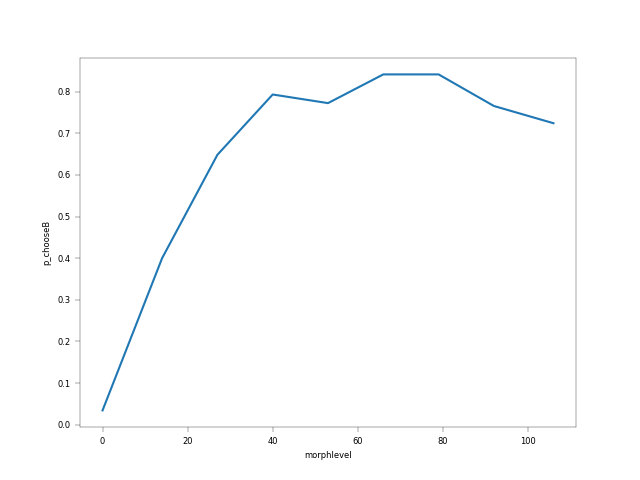

<AxesSubplot:xlabel='morphlevel', ylabel='p_chooseB'>

In [98]:
# test 1 
fig, ax = pl.subplots()
sns.lineplot(x='morphlevel', y='p_chooseB', data=df, ax=ax)

In [99]:
param_names = ['threshold', 'width', 'lambda', 'gamma', 'eta']
n_params = len(param_names)

opts = dict()
opts['sigmoidName'] = 'gauss'
opts['expType'] = 'YesNo'
opts['confP'] = np.tile(0.95, n_params)

# data: (np.array)
#     g[['morph_percent', 'n_chooseB', 'n_trials']]

In [100]:
importlib.reload(dec)

<module 'analyze2p.decoding' from '/net/coxfs01/srv/export/coxfs01/share_root/2p-pipeline/repos/rat-2p-area-characterizations/analyze2p/decoding.py'>

In [101]:
df_test = df.sort_values(by='morphlevel')
df_test

,morphlevel,n_samples,p_chooseB,n_chooseB,morph_percent
0,0,29,0.034483,1.0,0.000000
6,14,145,0.400000,58.0,0.132075
8,27,145,0.648276,94.0,0.254717
10,40,145,0.793103,115.0,0.377358
12,53,145,0.772414,112.0,0.500000
14,66,145,0.841379,122.0,0.622642
16,79,145,0.841379,122.0,0.745283
18,92,145,0.765517,111.0,0.867925
1,106,29,0.724138,21.0,1.000000


In [106]:
# fits = dec.psignifit_neurometric(df_test)

KeyboardInterrupt: 

In [ ]:
fits

In [109]:
data = df_test[['morph_percent', 'n_chooseB', 'n_samples']].values
res = ps.psignifit(data, opts)
print('Fit:', res['Fit'])

Fit: [1.43015352e-01 3.75291741e-01 1.96084740e-01 8.09782971e-08
 1.71561123e-07]


<IPython.core.display.Javascript object>


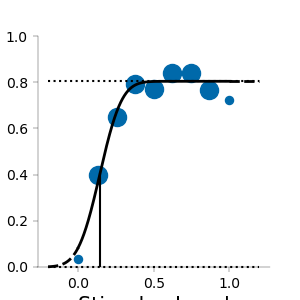

<AxesSubplot:xlabel='Stimulus Level', ylabel='Proportion Correct'>

In [110]:
fig, ax = pl.subplots(figsize=(3,3))
ps.psigniplot.plotPsych(res, axisHandle=ax)


In [113]:
res['options']


{'sigmoidName': 'gauss',
 'expType': 'YesNo',
 'confP': array([0.95, 0.95, 0.95, 0.95, 0.95]),
 'estimateType': 'MAP',
 'instantPlot': 0,
 'maxBorderValue': 1e-05,
 'moveBorders': 1,
 'dynamicGrid': 0,
 'widthalpha': 0.05,
 'threshPC': 0.5,
 'CImethod': 'percentiles',
 'gridSetType': 'cumDist',
 'fixedPars': array([nan, nan, nan, nan, nan]),
 'nblocks': 25,
 'useGPU': 0,
 'poolMaxGap': inf,
 'poolMaxLength': inf,
 'poolxTol': 0,
 'betaPrior': 10,
 'verbose': 0,
 'stimulusRange': array([0., 1.]),
 'fastOptim': False,
 'stepN': [40, 40, 20, 20, 20],
 'mbStepN': [25, 30, 10, 10, 15],
 'logspace': 0,
 'widthmin': 0.12264150943396224,
 'priors': [<function psignifit.priors.normalizeFunction.<locals>.<lambda>(x)>,
  <function psignifit.priors.normalizeFunction.<locals>.<lambda>(x)>,
  <function psignifit.priors.normalizeFunction.<locals>.<lambda>(x)>,
  <function psignifit.priors.normalizeFunction.<locals>.<lambda>(x)>,
  <function psignifit.priors.normalizeFunction.<locals>.<lambda>(x)>],
 

<IPython.core.display.Javascript object>


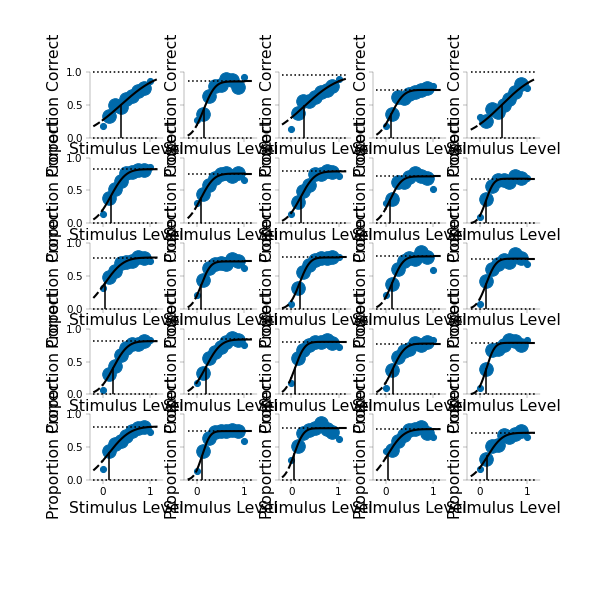

0, Fit: [3.86051215e-01 2.06038735e+00 2.58946579e-07 4.71729551e-05
 3.04810256e-09]
1, Fit: [1.39374215e-01 6.30866734e-01 1.43211417e-01 1.16312191e-08
 6.95664701e-02]
2, Fit: [2.72164751e-01 1.91849611e+00 4.10700131e-02 9.54249533e-08
 3.44196269e-07]
3, Fit: [1.19380055e-01 6.84742069e-01 2.71472614e-01 7.00602275e-09
 7.41219096e-09]
4, Fit: [4.58717301e-01 1.87268451e+00 5.56683432e-09 3.52926241e-06
 3.22969387e-07]
5, Fit: [1.70032604e-01 8.28398379e-01 1.77265108e-01 6.40682241e-08
 1.69746890e-08]
6, Fit: [7.92043364e-02 7.21580195e-01 2.43923562e-01 3.93413741e-08
 4.40426897e-06]
7, Fit: [1.92852406e-01 7.77797872e-01 2.09975622e-01 2.61779285e-08
 2.25276896e-05]
8, Fit: [9.07720154e-02 6.30888096e-01 2.86093172e-01 3.93738885e-06
 1.52043791e-08]
9, Fit: [1.20696473e-01 4.39148447e-01 3.21384739e-01 7.40872961e-05
 7.35334738e-08]
10, Fit: [4.62604801e-02 1.01813715e+00 2.19374209e-01 2.01408144e-08
 1.19767497e-07]
11, Fit: [8.66687119e-02 5.16772415e-01 2.78267406e-0

In [484]:
fig, axn = pl.subplots(5, 5, figsize=(8,8), sharex=True, sharey=True)
f_list=[]
n_iter=25
for ax, ni in zip(axn.flat, np.arange(0, n_iter)):
    data = df.loc[ni][['morph_percent', 'n_chooseB', 'n_samples']].values
    res = ps.psignifit(data, opts)
    print('%i, Fit:' % ni, res['Fit'])
    fit_ = pd.Series(res['Fit'], index=param_names, name=ni)
    f_list.append(fit_)
    ps.psigniplot.plotPsych(res, axisHandle=ax)

# figname = 'fit_%s_%s' % (sigmoid_, animalid)
# pl.savefig(os.path.join(curr_dst_dir, '%s.svg' % figname))
# print(curr_dst_dir, figname)

pl.subplots_adjust(left=0.15, bottom=0.2, wspace=0.3, hspace=0.3)

In [489]:
f_list=[]
n_iter=100
for ni in np.arange(0, n_iter):
    data = df.loc[ni][['morph_percent', 'n_chooseB', 'n_samples']].values
    res = ps.psignifit(data, opts)
    fit_ = pd.Series(res['Fit'], index=param_names, name=ni)
    f_list.append(fit_)

fitdf = pd.concat(f_list, axis=1).T
fitdf.head()

,threshold,width,lambda,gamma,eta
0,0.386051,2.060387,2.589466e-07,4.717296e-05,3.048103e-09
1,0.139374,0.630867,1.432114e-01,1.163122e-08,6.956647e-02
2,0.272165,1.918496,4.107001e-02,9.542495e-08,3.441963e-07
3,0.119380,0.684742,2.714726e-01,7.006023e-09,7.412191e-09
4,0.458717,1.872685,5.566834e-09,3.529262e-06,3.229694e-07


<IPython.core.display.Javascript object>


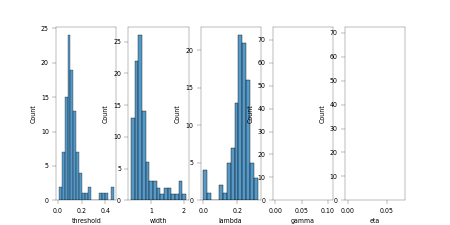

In [490]:

fig, axn = pl.subplots(1, len(param_names), figsize=(6,3))
for ax, param in zip(axn.flat, param_names):
    sns.histplot(x=param, data=fitdf, ax=ax, stat='count')
    

# test_type='morph_single'

In [118]:
# plotd = mean_df[mean_df['n_cells']<=max_ncells].copy()
finaldf['novel_labels'] = None
finaldf.loc[finaldf['novel'], 'novel_labels'] = 'novel'
finaldf.loc[~finaldf['novel'], 'novel_labels'] = 'trained'
#cond_colors = {'novel': 'cornflowerblue', 'trained': [0.3]*3}
novel_colors = {'trained': '', 'novel': (1,1)}

novel_colors = {'trained': [0.3]*3, 'novel': [0.7]*3}

In [119]:
# for k, g in mean_df.groupby(['n_cells', 'visual_area', 'condition', 'intact', 
#                  'train_transform', 'novel', 'morphlevel']):
#     g

In [146]:
finaldf.columns

Index(['fit_time', 'score_time', 'test_score', 'train_score',
       'heldout_test_score', 'C', 'randi', 'p_chooseB', 'morphlevel',
       'n_samples', 'condition', 'train_transform', 'test_transform', 'novel',
       'n_trials', 'iteration', 'randi_cells', 'n_cells', 'visual_area',
       'datakey', 'threshold', 'width', 'lambda', 'gamma', 'eta', 'intact',
       'noise_corrs', 'overlap_thr', 'novel_labels', 'test_case'],
      dtype='object')

In [120]:
curr_ncells=max_ncells
count_cols = ['visual_area', 'morphlevel', 'train_transform', 'test_case']

finaldf['test_case'] = ['novel' if n else 'trained' for n in finaldf['novel']]
datad = finaldf[(finaldf.condition=='data') & (finaldf.intact)
              & (finaldf.n_cells==curr_ncells)]
meandata_by_iter = datad.groupby(count_cols+['iteration']).mean()\
                     .reset_index()
print(meandata_by_iter['train_transform'].unique())

[10. 20. 30. 40. 50.]


In [121]:
n_iterations = float(iterdf['iteration'].max() +1)
assert meandata_by_iter.groupby(count_cols)\
    ['iteration'].count().max() == n_iterations, "Wrong iters: %.2f" % n_iterations

In [122]:
#### Set colors
metric='p_chooseB'
sz_cmap='viridis_r'
dashes={'trained': '', 'novel': (4,2)}
sizes = sorted(meandata_by_iter['train_transform'].unique())
print(sizes)
sz_cols = sns.color_palette(sz_cmap, n_colors=len(sizes))
sz_colors = dict((k, v) for k, v in zip(sizes, sz_cols))

[10.0, 20.0, 30.0, 40.0, 50.0]


In [123]:
print(curr_ncells)
mean_by_iter = finaldf[(finaldf.intact) & (finaldf.n_cells==curr_ncells)]

96


## Average morph curves (test on trained)

In [124]:
all_d = finaldf[(finaldf.intact) & (finaldf.n_cells==curr_ncells)]
all_mean_by_iter = all_d.groupby(count_cols+['iteration']).mean()\
                     .reset_index()

In [125]:
all_mean_by_iter['morphlevel'].unique()

array([ -1,   0,  14,  27,  40,  53,  66,  79,  92, 106])

/n/coxfs01/julianarhee/aggregate-visual-areas/decoding/py3_by_ncells/morphlevel/morph_single/dff-ROC__stimulus__overlap0.00__C1.00 neurometric_avg_train_configs__trained-only


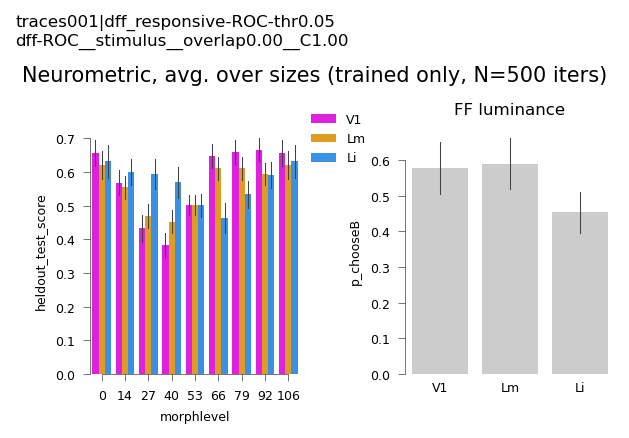

In [143]:
metric='heldout_test_score'
%matplotlib inline
plotd = mean_by_iter[mean_by_iter.test_case=='trained']\
            .groupby(['visual_area', 'morphlevel', 'iteration']).mean().reset_index()

fig, axn = pl.subplots(1,2, figsize=(5, 3), dpi=150, sharex=False, sharey=False)
ax=axn[0]
sns.barplot(x='morphlevel', y=metric, ax=ax, data=plotd[plotd.morphlevel!=-1], 
            hue='visual_area', hue_order=visual_areas, ci='sd', dodge=0.5, 
            palette=area_colors, errwidth=0.5)
ax.legend(bbox_to_anchor=(1., 1.1), loc='upper left', frameon=False)
#ax.axhline(y=0.5, ls=':', lw=0.5, color='k')
#ax.set_ylim([0, 1])
#pplot.set_morph_xticks(ax) 
sns.despine(trim=True, ax=ax)

ax=axn[1]
lumd = plotd[plotd.morphlevel==-1]\
            .groupby(['visual_area', 'morphlevel', 'iteration']).mean().reset_index()

sns.barplot(x='visual_area', y='p_chooseB', ax=ax, data=lumd,
            ci='sd', order=visual_areas, color=[0.8]*3, errwidth=0.5)
ax.set_title('FF luminance')
#ax.set_aspect(6, anchor='C')
ax.set_xlabel('')
ax.tick_params(which='both', axis='x', size=0)
sns.despine(trim=True, bottom=True, ax=ax)

pl.subplots_adjust(left=0.1, right=0.8, bottom=0.2, top=0.75, wspace=0.5)

pplot.label_figure(fig, '%s\n%s' % (data_id, aggr_id))
fig.text(0.01, 0.85, \
         'Neurometric, avg. over sizes (trained only, N=%i iters)' % n_iterations)
figname = 'neurometric_avg_train_configs__trained-only'
pl.savefig(os.path.join(curr_dst_dir, '%s.svg' % figname))
print(curr_dst_dir, figname)

In [128]:
import itertools

## Average morph curves (trained vs. novel test configs)

/n/coxfs01/julianarhee/aggregate-visual-areas/decoding/py3_by_ncells/morphlevel/morph_single/dff-ROC__stimulus__overlap0.00__C1.00 neurometric_avg_train_configs__trained-v-novel


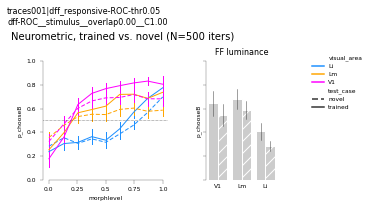

In [144]:
metric = 'p_chooseB'
plotd = meandata_by_iter.groupby(['visual_area', 'morphlevel', 'iteration', 'test_case'])\
                .mean().reset_index()

fig, axn = pl.subplots(1,2, figsize=(5, 3), sharex=False, sharey=True)
ax=axn[0]
sns.lineplot(x='morphlevel', y=metric, ax=ax, data=plotd[plotd.morphlevel!=-1], 
            hue='visual_area', palette=area_colors, 
            style='test_case', dashes=dashes, err_style='bars', ci='sd', 
            err_kws={'lw': 1}, lw=1)
ax.legend(bbox_to_anchor=(2.1, 1.1), loc='upper left', frameon=False)
ax.axhline(y=0.5, ls=':', lw=0.5, color='k')
ax.set_ylim([0, 1])
pplot.set_morph_xticks(ax) 
sns.despine(trim=True, ax=ax)

ax=axn[1]
sns.barplot(x='visual_area', y='p_chooseB', ax=ax, 
            data=plotd[plotd.morphlevel==-1], hue='test_case',
            ci='sd', order=visual_areas, hue_order=['trained', 'novel'],
            palette={'trained': [0.8]*3, 'novel': [0.8]*3}, errwidth=0.5,
           edgecolor='w')
bar_locs = 3
hatches = itertools.cycle(['', '//'])
for i, bar in enumerate(ax.patches):
    if i % bar_locs == 0:
        hatch = next(hatches)
    bar.set_hatch(hatch)
ax.set_aspect(6, anchor='SW')
ax.legend_.remove()
ax.set_xlabel('')
ax.set_title('FF luminance')
ax.set_aspect(5, anchor='SW')
ax.tick_params(which='both', axis='x', size=0)
sns.despine(trim=True, bottom=True, ax=ax)

pl.subplots_adjust(left=0.1, right=0.9, bottom=0.2, top=0.75, wspace=0.3)

pplot.label_figure(fig, '%s\n%s' % (data_id, aggr_id))
fig.text(0.01, 0.85, 'Neurometric, trained vs. novel (N=%i iters)' % n_iterations)
figname = 'neurometric_avg_train_configs__trained-v-novel'
pl.savefig(os.path.join(curr_dst_dir, '%s.svg' % figname))
print(curr_dst_dir, figname)

In [130]:
mean_by_iter

,fit_time,score_time,test_score,train_score,heldout_test_score,C,randi,p_chooseB,morphlevel,n_samples,...,threshold,width,lambda,gamma,eta,intact,noise_corrs,overlap_thr,novel_labels,test_case
1800000,0.213106,0.000663,0.766667,1.0,0.750000,1.0,8336,0.250000,0,4,...,NaN,NaN,NaN,NaN,NaN,True,intact,0.0,trained,trained
1800001,0.213106,0.000663,0.766667,1.0,0.750000,1.0,8336,0.750000,106,4,...,NaN,NaN,NaN,NaN,NaN,True,intact,0.0,trained,trained
1800002,0.000721,0.000289,0.400000,1.0,0.625000,1.0,8336,0.500000,0,4,...,NaN,NaN,NaN,NaN,NaN,True,intact,0.0,trained,trained
1800003,0.000721,0.000289,0.400000,1.0,0.625000,1.0,8336,0.750000,106,4,...,NaN,NaN,NaN,NaN,NaN,True,intact,0.0,trained,trained
1800004,0.213106,0.000663,0.766667,1.0,0.421053,1.0,8336,0.947368,-1,19,...,NaN,NaN,NaN,NaN,NaN,True,intact,0.0,trained,trained
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4799995,0.000809,0.000343,0.935556,1.0,0.103448,1.0,1624,0.103448,106,29,...,NaN,NaN,NaN,NaN,NaN,True,intact,0.0,novel,novel
4799996,0.000809,0.000343,0.935556,1.0,0.965517,1.0,1624,0.965517,106,29,...,NaN,NaN,NaN,NaN,NaN,True,intact,0.0,novel,novel
4799997,0.000809,0.000343,0.935556,1.0,0.275862,1.0,1624,0.275862,106,29,...,NaN,NaN,NaN,NaN,NaN,True,intact,0.0,novel,novel
4799998,0.000809,0.000343,0.935556,1.0,1.000000,1.0,1624,1.000000,106,29,...,NaN,NaN,NaN,NaN,NaN,True,intact,0.0,novel,novel


# Neurometric, splt by train config (trained only)

/n/coxfs01/julianarhee/aggregate-visual-areas/decoding/py3_by_ncells/morphlevel/morph_single/dff-ROC__stimulus__overlap0.00__C1.00 pchooseB_overlay_hue_test-on-trained


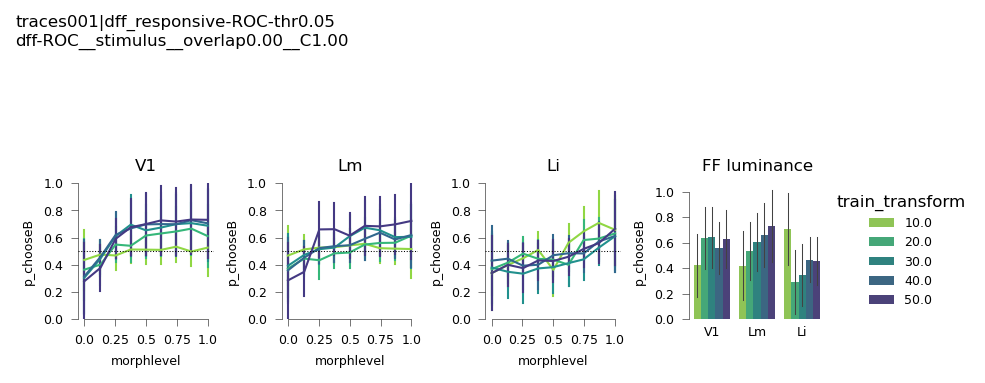

In [145]:
plotd = mean_by_iter[mean_by_iter.test_case=='trained']

fig, axn = pl.subplots(1,4, figsize=(6, 3), dpi=150, sharex=False, sharey=False)
for va, vg in plotd[plotd.morphlevel!=-1].groupby('visual_area'):
    ax=axn[visual_areas.index(va)]
    sns.lineplot(x='morphlevel', y=metric, ax=ax, data=vg, 
                #style='test_case', dashes=dashes,
                hue='train_transform', err_style='bars', ci='sd', 
                palette=sz_colors, err_kws={'lw': 1}, lw=1)
    ax.set_title(va)
    ax.legend_.remove()
    ax.axhline(y=0.5, ls=':', lw=0.5, color='k')
    ax.set_ylim([0, 1])
    # ax.set_yticklabels(np.linspace(0, 1, 6))
    pplot.set_morph_xticks(ax) 
    sns.despine(trim=True, ax=ax)

ax=axn[3]
lumd = plotd[plotd.morphlevel==-1]

sns.barplot(x='visual_area', y='p_chooseB', ax=ax, 
            data=lumd,
            hue='train_transform', ci='sd', order=visual_areas, palette=sz_colors,
            errwidth=0.5)
ax.set_title('FF luminance')
ax.legend(bbox_to_anchor=(1,1), loc='upper left', frameon=False,
              title='train_transform')
ax.tick_params(which='both', axis='x', size=0)
ax.set_xlabel('')
sns.despine(trim=True, bottom=True, ax=ax)

for ax in axn.flat:
    ax.set_box_aspect(1)
    
pl.subplots_adjust(left=0.07, right=0.9, bottom=0.2, top=0.75, wspace=0.5)

pplot.label_figure(fig, '%s\n%s' % (data_id, aggr_id))
figname = 'pchooseB_overlay_hue_test-on-trained'
pl.savefig(os.path.join(curr_dst_dir, '%s.svg' % figname))
print(curr_dst_dir, figname)

## Neurometric, split by config (trained v novel)

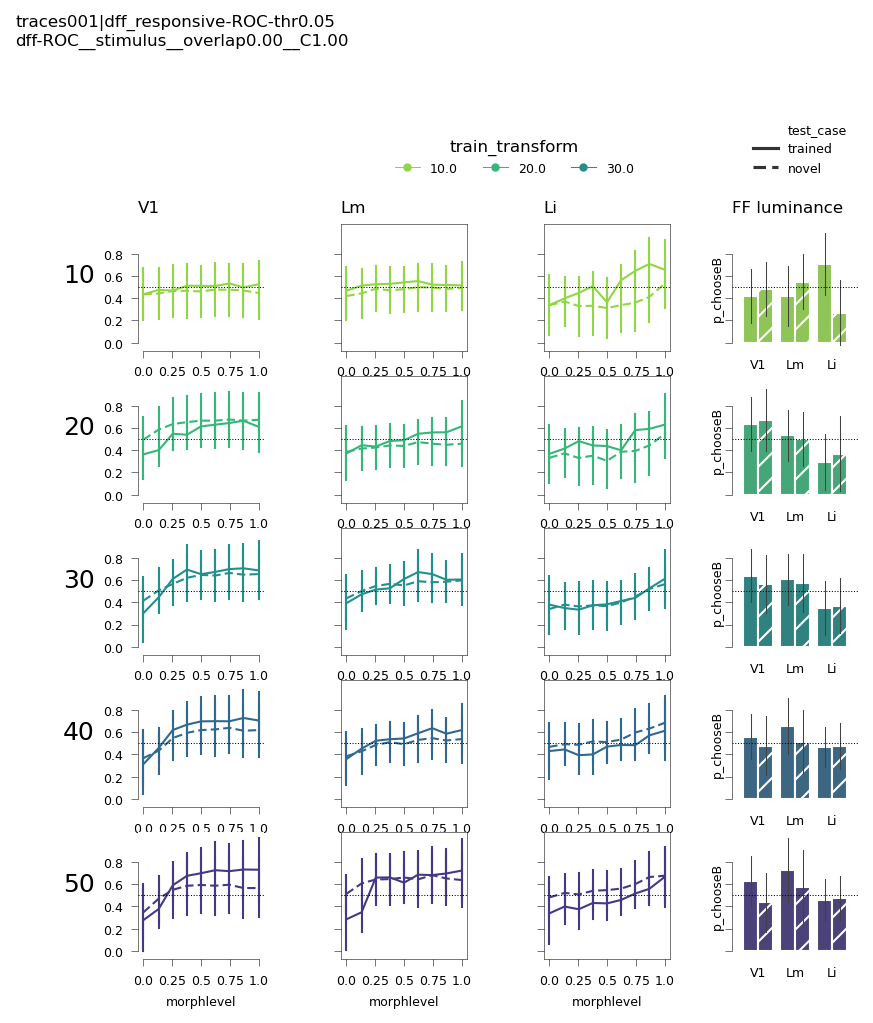

In [141]:
fig, axn = pl.subplots(len(sizes), 4, figsize=(6, 7), dpi=150, sharex=False, sharey=True)
for si, (sz, sg) in enumerate(mean_by_iter.groupby(['train_transform'])):
    for va, vg in sg[sg.morphlevel!=-1].groupby('visual_area'):
        ax=axn[si, visual_areas.index(va)]
        sns.lineplot(x='morphlevel', y=metric, ax=ax, data=vg, 
                    style='test_case', dashes=dashes,
                    hue='train_transform', err_style='bars', ci='sd', 
                    palette=sz_colors, err_kws={'lw': 1}, lw=1)
        pplot.set_morph_xticks(ax) 
#         ax.set_xticks(np.linspace(0, 106, 5))
#         ax.set_xticklabels(np.linspace(0, 1, 5))
        if si==0:
            ax.set_title(va, loc='left', fontsize=8)
        #ax.legend_.remove()
    ax.set_ylabel(int(sz), rotation=0, ha='right', fontsize=12)
    sns.despine(trim=True, ax=ax)

    ax=axn[si, 3]
    bardf = sg[sg.morphlevel==-1]
    sns.barplot(x='visual_area', y='p_chooseB', ax=ax, 
                data=bardf, order=visual_areas, edgecolor='w',
                hue='test_case', ci='sd', hue_order=['trained', 'novel'],
                palette={'trained': sz_colors[sz], 'novel': sz_colors[sz]},
                errwidth=0.5)
    bar_locs = len(bardf.visual_area.unique())
    hatches = itertools.cycle(['', '//'])
    for i, bar in enumerate(ax.patches):
        if i % bar_locs == 0:
            hatch = next(hatches)
        bar.set_hatch(hatch)
    ax.set_aspect(3, anchor='SW')
    #ax.legend_.remove()
    if si==0:   
        ax.set_title('FF luminance', loc='left', fontsize=8)
    ax.tick_params(which='both', axis='x', size=0)
    ax.set_xlabel('')
    sns.despine(trim=True, bottom=True, ax=ax)
        
for ai, ax in enumerate(axn.flat):
    #ax.legend_.remove()
    ax.axhline(y=0.5, ls=':', color='k', lw=0.5)
    #ax = axn[0, 2]
    if ai==3:  # Add LINEPLOT legend to far right
        leg_h = axn.flat[4].legend_.legendHandles[2:]
        ax.legend(handles=leg_h, bbox_to_anchor=(1,1.3), loc='lower right', 
                  frameon=False)
    elif ai==2: # Add COLOR LEGEND next to it
        leg_h = pplot.custom_legend_markers(colors=[sz_colors[s] for s in sizes],
                                           labels=sizes, markers='.')
        ax.legend(handles=leg_h, bbox_to_anchor=(0.8,1.3), loc='lower right',
                 frameon=False, title='train_transform', ncol=len(sizes))
    else:
        ax.legend_.remove()
    ax.set_box_aspect(1)
pl.subplots_adjust(left=0.12, right=0.97, bottom=0.1, top=0.8, wspace=0.3, hspace=0.2)

pplot.label_figure(fig, '%s\n%s' % (data_id, aggr_id))

figname = 'pchooseB_grid_hue_size_novel-v-trained'

pl.savefig(os.path.join(curr_dst_dir, '%s.svg' %figname))

In [139]:
sizes

[10.0, 20.0, 30.0, 40.0, 50.0]

In [ ]:
ax.legend(nc)

In [251]:
leg_h = ax.legend_.legendHandles[2:]
ax.legend(handles=leg_h, bbox_to_anchor


# Example FOV

In [513]:
print(experiment)
dk = '20191006_JC110_fov1'
va = 'V1'

nmetrics = NDATA0[(NDATA0.visual_area==va) & (NDATA0.datakey==dk)].copy()

gratings


In [10]:
# dk = '20190616_JC097_fov1'
# va = 'V1'
print(experiment)
sdf = aggr.get_master_sdf(experiment)

blobs


In [11]:


class_name='morphlevel' if experiment=='blobs' else 'ori'
if experiment=='gratings':
    variation_name = None
else:
    variation_name = None if test_type is None else 'size'
variation_values=None
class_a = 0 if class_name=='morphlevel' else None
class_b = 106 if class_name=='morphlevel' else None
print(class_name, class_a, class_b)
class_values = [class_a, class_b] if class_name=='morphlevel' \
            else sdf[class_name].unique()
clf_params={'class_name': class_name,
            'class_values': class_values,
            'variation_name': variation_name,
            'variation_values': variation_values,
            'n_train_configs': None,
            'C_value': C_value,
            'cv_nfolds': cv_nfolds,
            'test_split': test_split,
            'balance_configs':True,
            'do_shuffle': True,
            'return_clf': False,
            'verbose': False}

morphlevel 0 106


In [514]:
# stimuli
sdf = aggr.get_stimuli(dk, experiment)
# zscore data
ndf_z = aggr.get_zscored_from_ndf(nmetrics)
n_cells = int(ndf_z.shape[1]-1) 
print("... BY_FOV [%s] %s, n=%i cells" % (va, dk, n_cells))

... BY_FOV [V1] 20191006_JC110_fov1, n=93 cells


In [523]:
import copy
inargs = copy.copy(clf_params)


In [524]:
importlib.reload(dec)

<module 'analyze2p.decoding' from '/net/coxfs01/srv/export/coxfs01/share_root/2p-pipeline/repos/rat-2p-area-characterizations/analyze2p/decoding.py'>

In [525]:
inum=3
test_type=None
i_df = dec.select_test(inum, test_type, ndf_z, sdf, **inargs)
i_df

... 3 - selecting


,fit_time,score_time,test_score,train_score,heldout_MI,heldout_aMI,heldout_log2MI,heldout_test_score,C,randi,condition,n_cells,n_trials,iteration
3,0.472028,0.010411,0.255849,0.835691,0.289775,0.094974,0.418057,0.304688,1.0,606,data,93,1280,3
3,1.024186,0.010827,0.127958,0.648679,0.079508,-0.012930,0.114706,0.136719,1.0,606,shuffled,93,1280,3


In [509]:
importlib.reload(dec)

<module 'analyze2p.decoding' from '/net/coxfs01/srv/export/coxfs01/share_root/2p-pipeline/repos/rat-2p-area-characterizations/analyze2p/decoding.py'>

In [538]:
neuraldf = ndf_z.copy()
tvals = neuraldf.index.tolist()
neuraldf.loc[neuraldf.index, 'trial'] = tvals         


In [526]:
res = dec.fit_svm_mp(ndf_z, sdf, None, n_iterations=10, n_processes=1,
              **clf_params)

... 0 - selecting
--> Elapsed time: 12.50sec
... 1 - selecting
--> Elapsed time: 12.42sec
... 2 - selecting
--> Elapsed time: 12.68sec
... 3 - selecting
--> Elapsed time: 11.49sec
... 4 - selecting
--> Elapsed time: 13.12sec
... 5 - selecting
--> Elapsed time: 12.25sec
... 6 - selecting
--> Elapsed time: 12.25sec
... 7 - selecting
--> Elapsed time: 11.91sec
... 8 - selecting
--> Elapsed time: 11.87sec
... 9 - selecting
--> Elapsed time: 12.10sec


In [533]:
res[['train_score', 'test_score', 'heldout_test_score', 'condition']].groupby(['condition']).describe()

train_score                                                    \
                count      mean       std       min       25%       50%   
condition                                                                 
data             10.0  0.840819  0.010435  0.827876  0.831909  0.839475   
shuffled         10.0  0.616845  0.010824  0.597910  0.614318  0.617431   

                              test_score            ...                      \
                75%       max      count      mean  ...       75%       max   
condition                                           ...                       
data       0.848389  0.859373       10.0  0.258572  ...  0.265328  0.275371   
shuffled   0.621334  0.634036       10.0  0.124227  ...  0.133576  0.138661   

          heldout_test_score                                                   \
                       count      mean       std      min       25%       50%   
condition                                                                       
data                    10.0  0.273828  0.030002  0.21875  0.254883  0.275391   
shuffled                10.0  0.129688  0.023567  0.09375  0.110352  0.136719   

                               
                75%       max  
condition                      
data       0.294922  0.320312  
shuffled   0.146484  0.160156  

[2 rows x 24 columns]

In [365]:
inum =2
res = dec.do_fit_within_fov(inum, curr_data=ndf_z, sdf=sdf, 
                     C_value=C_value, test_split=test_split, cv_nfolds=cv_nfolds,
                     class_name=class_name, class_a=class_a, class_b=class_b, 
                     do_shuffle=True, balance_configs=True, return_clf=False)


/net/coxfs01/srv/export/coxfs01/share_root/2p-pipeline/repos/rat-2p-area-characterizations/analyze2p/aggregate_datasets.py:1182: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drop_trial_col = True


In [376]:
# inum =2
# res = dec.train_test_size

In [436]:
inum =2
class_name='morphlevel'
class_values = [0, 106]
variation_name='size'
variation_values = sorted(sdf[variation_name].unique())

res = dec.train_test_size_subset(inum, curr_data=ndf_z, sdf=sdf, 
                     C_value=C_value, test_split=test_split, cv_nfolds=cv_nfolds,
                     class_name=class_name, class_values=class_values,
                     variation_name=variation_name,
                     variation_values=variation_values,
                     n_train_configs=4,
                     do_shuffle=True, balance_configs=True, return_clf=False)


In [437]:
res

,fit_time,score_time,test_score,train_score,heldout_MI,heldout_aMI,heldout_log2MI,heldout_test_score,C,randi,condition,train_transform,test_transform,n_trials,novel,iteration,n_cells
0,0.006387,0.000969,0.706091,1.0,0.040743,0.045418,0.058780,0.641509,1.0,7228,data,10_20_30_40,10_20_30_40,264,False,2,221
1,0.008795,0.001038,0.492802,1.0,0.022424,0.019121,0.032351,0.396226,1.0,7228,shuffled,10_20_30_40,10_20_30_40,264,False,2,221
2,0.006387,0.000969,0.706091,1.0,0.084611,0.119522,0.122068,0.686567,1.0,7228,data,10_20_30_40,50.0,67,True,2,221
3,0.006277,0.000910,0.663677,1.0,0.102707,0.137532,0.148175,0.716981,1.0,9823,data,10_20_30_50,10_20_30_50,264,False,2,221
4,0.007357,0.000959,0.502436,1.0,0.000147,-0.014046,0.000213,0.490566,1.0,9823,shuffled,10_20_30_50,10_20_30_50,264,False,2,221
5,0.006277,0.000910,0.663677,1.0,0.111929,0.152264,0.161479,0.731343,1.0,9823,data,10_20_30_50,40.0,67,True,2,221
6,0.005600,0.000857,0.682835,1.0,0.001548,-0.011960,0.002234,0.528302,1.0,5767,data,10_20_40_50,10_20_40_50,264,False,2,221
7,0.008921,0.001029,0.426135,1.0,0.004288,-0.008155,0.006187,0.547170,1.0,5767,shuffled,10_20_40_50,10_20_40_50,264,False,2,221
8,0.005600,0.000857,0.682835,1.0,0.046699,0.058313,0.067372,0.647059,1.0,5767,data,10_20_40_50,30.0,68,True,2,221
9,0.005312,0.000805,0.668217,1.0,0.052276,0.062297,0.075418,0.660377,1.0,1688,data,10_30_40_50,10_30_40_50,264,False,2,221


In [430]:
importlib.reload(dec)

<module 'analyze2p.decoding' from '/net/coxfs01/srv/export/coxfs01/share_root/2p-pipeline/repos/rat-2p-area-characterizations/analyze2p/decoding.py'>

In [431]:
inum =2
class_name='morphlevel'
class_values = [0, 106]
variation_name='size'
variation_values = sorted(sdf[variation_name].unique())

res = dec.train_test_size_single(inum, curr_data=ndf_z, sdf=sdf, 
                     C_value=C_value, test_split=test_split, cv_nfolds=cv_nfolds,
                     class_name=class_name, class_values=class_values,
                     variation_name=variation_name,
                     variation_values=variation_values,
                     n_train_configs=4,
                     do_shuffle=True, balance_configs=True, return_clf=False)


1.0
(4,)
1.0
(4,)
0.610909090909091
(4,)
0.0020420074462890623
(4,)
0.0006659507751464843
(4,)
6564
(4,)
10.0
(4,)
1.0
(4,)
1.0
(4,)
0.7654545454545454
(4,)
0.0014920711517333984
(4,)
0.0004935741424560546
(4,)
5899
(4,)
20.0
(4,)
1.0
(4,)
1.0
(4,)
0.7781818181818183
(4,)
0.0015712738037109374
(4,)
0.0005093574523925781
(4,)
6167
(4,)
30.0
(4,)
1.0
(4,)
1.0
(4,)
0.730909090909091
(4,)
0.0014906883239746093
(4,)
0.0005062580108642578
(4,)
1901
(4,)
40.0
(4,)
1.0
(4,)
1.0
(4,)
0.6581818181818182
(4,)
0.0014026165008544922
(4,)
0.00045900344848632814
(4,)
1571
(4,)
50.0
(4,)


In [434]:
res.groupby(['condition', 'novel']).mean()

fit_time  score_time  test_score  train_score  heldout_MI  \
condition novel                                                              
data      False  0.001600    0.000527    0.708727          1.0    0.311854   
          True   0.001600    0.000527    0.708727          1.0    0.066433   
shuffled  False  0.001566    0.000512    0.535636          1.0    0.044120   

                 heldout_aMI  heldout_log2MI  heldout_test_score    C   randi  \
condition novel                                                                 
data      False     0.418541        0.449911            0.828571  1.0  4420.4   
          True      0.087560        0.095842            0.615979  1.0  4420.4   
shuffled  False     0.004287        0.063652            0.385714  1.0  4420.4   

                 train_transform  test_transform  n_trials  iteration  n_cells  
condition novel                                                                 
data      False             30.0            30.0      66.8        2.0    221.0  
          True              30.0            30.0      67.4        2.0    221.0  
shuffled  False             30.0            30.0      66.8        2.0    221.0

In [435]:
res

,fit_time,score_time,test_score,train_score,heldout_MI,heldout_aMI,heldout_log2MI,heldout_test_score,C,randi,condition,train_transform,test_transform,n_trials,novel,iteration,n_cells
0,0.002042,0.000666,0.610909,1.0,0.051757,0.014048,0.074670,0.642857,1.0,6564,data,10.0,10.0,68,False,2,221
1,0.001622,0.000542,0.536364,1.0,0.010239,-0.045851,0.014772,0.428571,1.0,6564,shuffled,10.0,10.0,68,False,2,221
2,0.002042,0.000666,0.610909,1.0,0.001906,-0.009494,0.002749,0.522388,1.0,6564,data,10.0,20.0,67,True,2,221
3,0.002042,0.000666,0.610909,1.0,0.004072,-0.005124,0.005874,0.455882,1.0,6564,data,10.0,30.0,68,True,2,221
4,0.002042,0.000666,0.610909,1.0,0.015436,0.012156,0.022270,0.417910,1.0,6564,data,10.0,40.0,67,True,2,221
5,0.002042,0.000666,0.610909,1.0,0.011254,0.005980,0.016236,0.447761,1.0,6564,data,10.0,50.0,67,True,2,221
6,0.001492,0.000494,0.765455,1.0,0.178715,0.213523,0.257831,0.785714,1.0,5899,data,20.0,20.0,66,False,2,221
7,0.001532,0.000509,0.536364,1.0,0.094878,0.083770,0.136879,0.285714,1.0,5899,shuffled,20.0,20.0,66,False,2,221
8,0.001492,0.000494,0.765455,1.0,0.000000,-0.010967,0.000000,0.500000,1.0,5899,data,20.0,10.0,68,True,2,221
9,0.001492,0.000494,0.765455,1.0,0.148230,0.205488,0.213851,0.764706,1.0,5899,data,20.0,30.0,68,True,2,221


In [323]:
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn import preprocessing
import sklearn.svm as svm
import sklearn.metrics as skmetrics

In [324]:
curr_data = ndf_z.copy()

In [325]:
#train_configs = sdf.index.tolist() 
train_configs = sdf[sdf[class_name].isin(classes)].index.tolist()

In [326]:
sample_data = curr_data[curr_data['config'].isin(train_configs)]
sample_data = aggr.equal_counts_df(sample_data)
sample_data

cell,0,5,7,18,19,23,28,29,31,32,...,269,281,288,301,302,312,313,320,328,config
trial,,,,,,,,,,,,,,,,,,,,,
1,0.078445,3.518986,2.386371,2.065101,1.772836,2.844329,6.966225,2.896976,0.653192,10.089535,...,-0.164878,8.258746,2.634527,2.821428,2.481068,0.051350,4.542824,2.827181,3.383868,config026
2,-1.152818,2.411491,-1.177954,-1.545042,-0.570205,-1.209613,-2.667617,1.343814,0.083505,4.195097,...,0.485428,2.386171,0.460740,-1.567966,0.821425,2.398091,0.324374,0.870920,1.180770,config010
3,0.653396,-0.478914,1.738281,0.001385,0.050060,0.559490,0.375340,-0.152469,-0.746372,-2.348391,...,-1.453632,-0.395428,-1.813270,-0.891581,-0.165115,-0.872763,-0.717911,-1.029094,-0.618699,config064
4,0.185509,3.109562,1.258647,1.130251,3.139119,2.926035,1.981328,2.537235,3.525917,3.392522,...,0.600094,3.968396,-2.109809,3.060546,2.697869,1.365633,1.174444,-0.252590,-0.690846,config049
5,0.078475,0.641078,-0.774927,0.050371,0.160926,0.657146,1.224734,-0.247175,-0.125525,-0.307120,...,-0.120079,-0.518387,1.194934,0.557252,-0.521050,-1.567678,-0.070270,-0.935974,-1.906833,config016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1276,-0.908171,-1.047119,-0.665546,-0.792583,-0.189404,-0.488754,-0.217741,0.785077,-1.084245,-0.527047,...,1.143603,-0.249548,0.400215,-1.178330,-0.037441,-0.708547,-0.409609,-1.561999,1.337479,config036
1277,-0.950673,0.268023,-0.629667,-0.320041,-0.581986,-0.839074,-0.043377,0.029160,0.095245,0.118334,...,-0.134356,-0.735776,-0.139399,-0.779681,0.012811,-0.048304,-0.166939,0.786257,-0.632552,config020
1278,0.689772,-0.785139,-0.222806,-0.573672,-0.244134,0.766249,-0.241643,-0.316434,-0.208946,0.138407,...,0.189678,0.926258,1.687781,0.384967,0.557723,0.457051,0.216065,-0.821144,-0.463522,config046


In [367]:
test = sample_data.drop('config', 1)
test.shape, sample_data.shape


((1280, 93), (1280, 94))

In [371]:
(test.values - zdata.values).max()


0.0

In [347]:
targets = pd.DataFrame(sample_data['config'].copy(), columns=['config'])
targets['label'] = sdf.loc[targets['config'].values][class_name].astype(int).values

In [348]:
rois_ = [r for r in sample_data.columns if hutils.isnumber(r)]
zdata= sample_data[rois_].copy()
len(rois_), zdata.shape

(93, (1280, 93))

In [352]:
randi=100
clf_params={'C_value': C_value,
            'cv_nfolds': cv_nfolds,
            'test_split': test_split,
            'randi': randi,
            'return_clf': False,
            'verbose': False}

In [353]:
citer = dec.fit_svm(zdata, targets, **clf_params)

In [354]:
citer

{'fit_time': 0.4293060779571533,
 'score_time': 0.009502601623535157,
 'test_score': 0.2627116212338594,
 'train_score': 0.8334923612972392,
 'heldout_MI': 0.25045956622441773,
 'heldout_aMI': 0.07479709081582958,
 'heldout_log2MI': 0.3613367741351682,
 'heldout_test_score': 0.25390625,
 'C': 1.0,
 'randi': 100}

In [329]:

train_data, test_data, train_labels, test_labels = train_test_split(zdata,
                                                            targets['label'].values,
                                                            test_size=test_split,
                                                            stratify=targets['label'],
                                                            shuffle=True,
                                                            random_state=randi)


In [330]:
pd.DataFrame(train_labels).value_counts()

0      128
45     128
90     128
135    128
180    128
225    128
270    128
315    128
dtype: int64

In [331]:
scaler = preprocessing.StandardScaler().fit(train_data)
train_data = scaler.transform(train_data)
svc_ = svm.SVC(kernel='linear', C=C_value, random_state=randi,
              decision_function_shape='ovr')

In [332]:
scores = cross_validate(svc_, train_data, train_labels, cv=5,
                        scoring=('accuracy'), 
                        return_train_score=True)
scores


{'fit_time': array([0.47146988, 0.47107625, 0.38281775, 0.44801259, 0.41353726]),
 'score_time': array([0.01139474, 0.00999784, 0.00940156, 0.00930309, 0.00928378]),
 'test_score': array([0.28780488, 0.27317073, 0.25853659, 0.21463415, 0.27941176]),
 'train_score': array([0.84249084, 0.83394383, 0.81929182, 0.82295482, 0.84878049])}

In [333]:
trained_svc = svc_.fit(train_data, train_labels)

In [334]:
test_data = scaler.transform(test_data)
test_score = trained_svc.score(test_data, test_labels)
predicted_labels = trained_svc.predict(test_data)


<IPython.core.display.Javascript object>


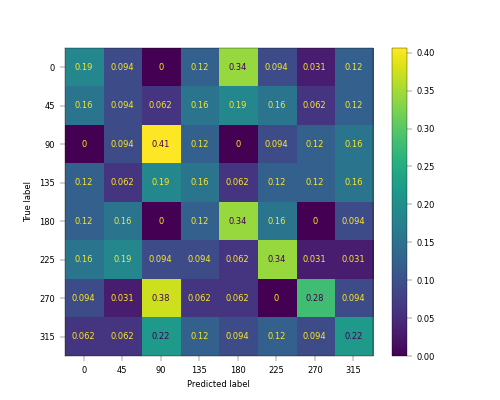

In [341]:
skmetrics.plot_confusion_matrix(trained_svc, test_data, test_labels, 
                                normalize='true')  

In [11]:
def wraper_func(func, **kwargs):
    output = func(**kwargs)
    return output

In [20]:
def func1(x='Func1', y='Alt1', z='Extra1'):
    res = '%s_%s_%s' % (x, y, z)
    return res

def func2(x='Func2', y='Alt2', w='Extra2'):
    res = '%s_%s_%s' % (x, y, z)
    r2 = 'andthis'
    return res, r2

In [23]:
inargs = {'x': 'check1', 'z': 'check2'}
inargs = (x='check1', y='check2')
res = wraper_func(func1, **inargs)
res

SyntaxError: invalid syntax (<ipython-input-23-0a6f99e4a23c>, line 2)

In [22]:
res = wraper_func(func2, **inargs)
res

TypeError: func2() got an unexpected keyword argument 'z'

In [ ]:
decode_from_fov(dk, va, neuraldf, sdf, C_value=C_value,
                        n_iterations=n_iterations, n_processes=n_processes, results_id=results_id,
                        class_a=class_a, class_b=class_b, do_shuffle=do_shuffle,
                        rootdir=rootdir, verbose=verbose,
                        test_type=test_type, n_train_configs=n_train_configs) 
            print("--- done by_fov ---")